# Streamflow Forecasting with a Hybrid LSTM + XGBoost Pipeline

A two-stage model for predicting daily streamflow change (`streamflow_delta`) across 367 gauging stations.  
The LSTM captures temporal patterns in hydrological sequences, and XGBoost corrects the residuals using the LSTM hidden state alongside static basin features.

---
**Dataset:** 3.2M rows | 52 features | 367 stations  
**Target:** `streamflow_delta` (standardised day-over-day flow change)  
**Final raw-flow NSE:** 0.9996 | **KGE:** 0.9990

---
## 1. Kaggle Environment Check

Verify input file paths available in the Kaggle filesystem.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sridipbasu/flood-hydro/processed_hydrology_data.csv


## 1. Environment

List all available input files in the Kaggle filesystem.

In [2]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sridipbasu/flood-hydro/processed_hydrology_data.csv


## 2. Imports and Hardware Setup

Load the core libraries and check which GPU(s) are available. The active device is used throughout the notebook.

In [3]:
import pandas as pd
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("=" * 55)
print("Device Info")
print("=" * 55)
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f" GPU {i}: {props.name} | {props.total_memory/1e9:.2f} GB")
print(f" Active device: {device}")

Device Info
 GPU 0: Tesla T4 | 15.64 GB
 GPU 1: Tesla T4 | 15.64 GB
 Active device: cuda


## 3. Load and Explore the Dataset

Read the raw CSV and check the overall shape, the train/test split proportions, any missing values, and the distribution of the target columns.

In [4]:
DATA_PATH = "/kaggle/input/datasets/sridipbasu/flood-hydro/processed_hydrology_data.csv"
df = pd.read_csv(DATA_PATH)

print("\n" + "=" * 55)
print("Dataset Overview")
print("=" * 55)
print(f" Shape        : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f" Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

print("\n" + "=" * 55)
print("Dataset Split")
print("=" * 55)
split_counts = df['dataset_split'].value_counts()
split_pct    = df['dataset_split'].value_counts(normalize=True) * 100
for s in split_counts.index:
    print(f" {s:<10}: {split_counts[s]:>7,} rows ({split_pct[s]:.1f}%)")

print("\n" + "=" * 55)
print("Missing Values")
print("=" * 55)
null_counts = df.isnull().sum()
null_cols   = null_counts[null_counts > 0].sort_values(ascending=False)
if len(null_cols) == 0:
    print(" No missing values found.")
else:
    null_df = pd.DataFrame({
        'count': null_cols,
        'pct_%': (null_cols / len(df) * 100).round(3)
    })
    print(null_df.to_string())

candidates = ['estimated_return_period','flow_rp15_ratio',
              'streamflow_delta','prev_raw_streamflow']
existing = [c for c in candidates if c in df.columns]
print("\n" + "=" * 55)
print("Target Column Stats")
print("=" * 55)
print(df[existing].describe().round(4).to_string())

print("\nDone.")


Dataset Overview
 Shape        : 3,213,819 rows x 52 columns
 Memory usage : 1484.14 MB

Dataset Split
 train     : 2,571,055 rows (80.0%)
 test      : 642,764 rows (20.0%)

Missing Values
                                         count   pct_%
upstream_weighted_streamflow_log_delta  455679  14.179
upstream_weighted_streamflow_log        455364  14.169

Target Column Stats
       estimated_return_period  flow_rp15_ratio  streamflow_delta  prev_raw_streamflow
count             3.213819e+06     3.213819e+06      3.213819e+06         3.213819e+06
mean              4.000000e-03     2.240000e-02      0.000000e+00         1.235073e+03
std               9.691000e-01     9.977000e-01      1.030400e+00         2.195675e+03
min              -3.575000e-01    -9.683000e-01     -2.079330e+01         1.082640e+01
25%              -2.263000e-01    -5.599000e-01     -6.700000e-02         2.283246e+02
50%              -1.661000e-01    -3.767000e-01     -1.050000e-02         5.003979e+02
75%            

### Sanity check: what is the maximum streamflow delta value in the dataset?

In [5]:
df['streamflow_delta'].max()

73.11960863006121

## 4. Preprocessing

### 4.1 Station ID Recovery

There is no explicit station ID column in the raw data. We fingerprint each unique station by hashing its set of static physical attributes — basin area, slope, land cover fractions, flow velocity, and so on. This gives every row a consistent integer `station_id` without needing any external lookup table.

In [6]:
import gc

DATA_PATH  = "/kaggle/input/datasets/sridipbasu/flood-hydro/processed_hydrology_data.csv"
df = pd.read_csv(DATA_PATH)

TARGET_COL = 'streamflow_delta'
STATE_COL  = 'prev_raw_streamflow'
ADMIN_COL  = 'dataset_split'

STATIC_COLS = [
    'UP_AREA_yj', 'DIST_SINK', 'slp_dg', 'slp_dg_uav',
    'for_pc', 'urb_pc', 'attenuation_factor',
    'flow_velocity_km_per_day', 'upstream_lag1_days', 'upstream_lag2_days'
]

print("=" * 60)
print("Station ID Recovery")
print("=" * 60)
static_rounded = df[STATIC_COLS].round(6)
df['station_id'] = static_rounded.apply(lambda r: hash(tuple(r)), axis=1)
unique_hashes    = df['station_id'].unique()
df['station_id'] = df['station_id'].map({h: i for i, h in enumerate(unique_hashes)})

n_stations       = df['station_id'].nunique()
rows_per_station = df.groupby('station_id').size()
print(f" Recovered stations : {n_stations:,}")
print(f" Rows per station   : min={rows_per_station.min()}, "
      f"max={rows_per_station.max()}, "
      f"median={rows_per_station.median():.0f}")

Station ID Recovery
 Recovered stations : 367
 Rows per station   : min=8757, max=8757, median=8757


### 4.2 NaN Imputation, Split Verification and Save

About 14% of the upstream-weighted flow features are NaN — these come from stations that have no upstream neighbours. We fill them per-station with forward-fill, then back-fill, then zero for any remaining gaps. After that we verify the train/test split and save the cleaned dataframe as Parquet for faster loading downstream.

In [7]:
# NaN Imputation (within station, forward-fill -> backfill -> 0)
print("\n" + "=" * 60)
print("NaN Imputation")
print("=" * 60)
NAN_COLS = ['upstream_weighted_streamflow_log',
            'upstream_weighted_streamflow_log_delta']

before = df[NAN_COLS].isnull().sum()
df[NAN_COLS] = (
    df.groupby('station_id')[NAN_COLS]
    .transform(lambda x: x.ffill().bfill())
)
df[NAN_COLS] = df[NAN_COLS].fillna(0)
after = df[NAN_COLS].isnull().sum()

for col in NAN_COLS:
    print(f" {col}")
    print(f"   {before[col]:,} NaN -> {after[col]:,} NaN")
print(f"\n Total remaining NaN: {df[NAN_COLS].isnull().sum().sum()}")

print("\n" + "=" * 60)
print("Split Verification")
print("=" * 60)
train_df = df[df[ADMIN_COL] == 'train']
test_df  = df[df[ADMIN_COL] == 'test']
print(f" Train rows : {len(train_df):,}")
print(f" Test rows  : {len(test_df):,}")
overlap = set(train_df['station_id']) & set(test_df['station_id'])
print(f" Shared stations (temporal split): {len(overlap)}")

SAVE_PATH = "/kaggle/working/flood_preprocessed.parquet"
df.to_parquet(SAVE_PATH, index=False)
print(f"\n Saved to: {SAVE_PATH}")
print(f" Final shape: {df.shape}")


NaN Imputation
 upstream_weighted_streamflow_log
   455,364 NaN -> 0 NaN
 upstream_weighted_streamflow_log_delta
   455,679 NaN -> 0 NaN

 Total remaining NaN: 0

Split Verification
 Train rows : 2,571,055
 Test rows  : 642,764
 Shared stations (temporal split): 367

 Saved to: /kaggle/working/flood_preprocessed.parquet
 Final shape: (3213819, 53)


## 5. Configuration and Feature Engineering

### 5.1 Hyperparameters and Feature Split

All training constants are defined here. The 42 available features are then split into two groups:

- **Dynamic features (32)** — time-varying inputs that go into the LSTM sequence each step
- **Static features (10)** — basin-level constants that are fixed per station and fed only to XGBoost
- **Flat features (42)** — all features concatenated with the 256-dim LSTM hidden state to form the full XGBoost input (298 features total)

Seven redundant or leaky columns are dropped before anything is fed to the model.

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import gc

TARGET_COL  = 'streamflow_delta'
STATE_COL   = 'prev_raw_streamflow'
ADMIN_COL   = 'dataset_split'
SEQ_LEN     = 15
BATCH_SIZE  = 2048
HIDDEN_SIZE = 256   # <- CHANGED: 128->256 (more capacity for dual-regime targets)
NUM_LAYERS  = 2
DROPOUT     = 0.2   # <- CHANGED: 0.4->0.2 (less aggressive; baseflow is smooth/low-amplitude)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f" Using {n_gpus} GPU(s): {device}")

STATIC_COLS = [
    'UP_AREA_yj', 'DIST_SINK', 'slp_dg', 'slp_dg_uav',
    'for_pc', 'urb_pc', 'attenuation_factor',
    'flow_velocity_km_per_day', 'upstream_lag1_days', 'upstream_lag2_days'
]

print("\n" + "=" * 65)
print("Loading Preprocessed Data")
print("=" * 65)
df = pd.read_parquet("/kaggle/working/flood_preprocessed.parquet")
print(f"  Shape: {df.shape}")

print("\n" + "=" * 65)
print("Feature Lists")
print("=" * 65)

ALL_EXCLUDE  = [TARGET_COL, STATE_COL, ADMIN_COL, 'station_id']
FLAT_COLS    = [c for c in df.columns if c not in ALL_EXCLUDE]
DYNAMIC_COLS = [c for c in FLAT_COLS if c not in STATIC_COLS]

DROP_COLS = [
    'rainfall_anomaly_zscore',
    'streamflow_anomaly_zscore',
    'flow_rp15_ratio',
    'antecedent_rain_3d_mean',
    'antecedent_rain_7d_mean',
    'antecedent_rain_15d_mean',
    'antecedent_rain_30d_mean',
]

DYNAMIC_COLS = [c for c in DYNAMIC_COLS if c not in DROP_COLS]
FLAT_COLS    = [c for c in FLAT_COLS    if c not in DROP_COLS]
N_DYNAMIC    = len(DYNAMIC_COLS)
N_FLAT       = len(FLAT_COLS)
N_XGB_IN     = N_FLAT + HIDDEN_SIZE

print(f"  Dropped columns : {len(DROP_COLS)}")
for c in DROP_COLS:
    print(f"    {c}")
print(f"\n  Static features   : {len(STATIC_COLS)} (XGBoost flat only)")
print(f"  Dynamic features  : {N_DYNAMIC} (LSTM input_size)")
print(f"  Flat features     : {N_FLAT} (all -> XGBoost)")
print(f"  XGBoost input dim : {N_XGB_IN} (flat + hidden state)")
print(f"\n  Dynamic feature list:")
for i, c in enumerate(DYNAMIC_COLS):
    print(f"    [{i:02d}] {c}")

 Using 2 GPU(s): cuda

Loading Preprocessed Data
  Shape: (3213819, 53)

Feature Lists
  Dropped columns : 7
    rainfall_anomaly_zscore
    streamflow_anomaly_zscore
    flow_rp15_ratio
    antecedent_rain_3d_mean
    antecedent_rain_7d_mean
    antecedent_rain_15d_mean
    antecedent_rain_30d_mean

  Static features   : 10 (XGBoost flat only)
  Dynamic features  : 32 (LSTM input_size)
  Flat features     : 42 (all -> XGBoost)
  XGBoost input dim : 298 (flat + hidden state)

  Dynamic feature list:
    [00] estimated_return_period
    [01] upstream_rain_mean_yj
    [02] weighted_upstream_rain_yj
    [03] upstream_rain_lagged_dist_sink
    [04] antecedent_rain_3d_sum
    [05] antecedent_rain_7d_sum
    [06] antecedent_rain_15d_sum
    [07] antecedent_rain_30d_sum
    [08] antecedent_rain_ewm
    [09] flow_rate_of_change
    [10] monsoon_intensity
    [11] is_post_monsoon_saturated
    [12] monsoon_cumulative_rain
    [13] rainfall_mm_log
    [14] upstream_weighted_streamflow_log
    [1

### 5.2 Per-Station Data Arrays

Group the dataframe by `station_id` and store each station's feature matrices, targets, and split labels as pre-allocated NumPy arrays. This avoids repeated groupby calls inside the DataLoader hot path and makes index construction much faster.

In [9]:
print("\n" + "=" * 65)
print("Per-Station Arrays")
print("=" * 65)

station_dynamic = {}
station_flat    = {}
station_targets = {}
station_splits  = {}

for sid, group in df.groupby('station_id'):
    station_dynamic[sid] = group[DYNAMIC_COLS].values.astype(np.float32)
    station_flat[sid]    = group[FLAT_COLS].values.astype(np.float32)
    station_targets[sid] = group[TARGET_COL].values.astype(np.float32)
    station_splits[sid]  = group[ADMIN_COL].values

print(f"  Stations loaded : {len(station_dynamic)}")
print(f"  Dynamic shape   : {station_dynamic[0].shape}")
print(f"  Flat shape      : {station_flat[0].shape}")
gc.collect()


Per-Station Arrays
  Stations loaded : 367
  Dynamic shape   : (8757, 32)
  Flat shape      : (8757, 42)


30

### 5.3 Custom Dataset and DataLoaders

`FloodHybridDataset` builds a flat `(station_id, time_step)` index so no sequence ever crosses a station boundary. Three loaders are created:

- `train_loader` — shuffled, used during LSTM backprop
- `ordered_train_loader` — same data unshuffled, used after training to collect residuals for XGBoost
- `test_loader` — unshuffled, used for all evaluation

In [10]:
print("\n" + "=" * 65)
print("Hybrid Dataset")
print("=" * 65)

class FloodHybridDataset(Dataset):
    """
    Returns per sample:
      X_dyn  : (SEQ_LEN, N_DYNAMIC) -> LSTM
      X_flat : (N_FLAT,)            -> XGBoost
      y      : scalar               -> streamflow_delta at pred row
    No cross-station sequences ever created.
    """
    def __init__(self, station_dynamic, station_flat, station_targets,
                 station_splits, seq_len, split='train'):
        self.seq_len = seq_len
        self.dyn     = station_dynamic
        self.flat    = station_flat
        self.y       = station_targets
        self.index   = []
        for sid in sorted(station_dynamic.keys()):
            n      = len(station_dynamic[sid])
            splits = station_splits[sid]
            for t in range(n - seq_len):
                if splits[t + seq_len] == split:
                    self.index.append((sid, t))
        print(f"  [{split}] sequences: {len(self.index):,}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sid, t  = self.index[idx]
        X_dyn   = self.dyn[sid][t : t + self.seq_len]
        X_flat  = self.flat[sid][t + self.seq_len]
        y       = self.y[sid][t + self.seq_len]
        return (torch.from_numpy(X_dyn),
                torch.from_numpy(X_flat),
                torch.tensor(y))

train_dataset = FloodHybridDataset(
    station_dynamic, station_flat, station_targets,
    station_splits, SEQ_LEN, split='train'
)
test_dataset = FloodHybridDataset(
    station_dynamic, station_flat, station_targets,
    station_splits, SEQ_LEN, split='test'
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, prefetch_factor=2
)
ordered_train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"\n  Train batches (shuffled) : {len(train_loader):,}")
print(f"  Train batches (ordered)  : {len(ordered_train_loader):,}")
print(f"  Test batches             : {len(test_loader):,}")


Hybrid Dataset
  [train] sequences: 2,565,550
  [test] sequences: 642,764

  Train batches (shuffled) : 1,253
  Train batches (ordered)  : 627
  Test batches             : 157


## 6. Model Architecture

### 6.1 LSTM

A 2-layer LSTM over the 32 dynamic features, followed by LayerNorm, Dropout, GELU activation, and a linear output head. When `return_hidden=True`, the final hidden state is returned alongside the prediction so XGBoost can use it as additional input.

Design decisions worth noting:
- Hidden size raised to **256** — handles both the quiet baseflow regime and flood spikes better than 128
- Dropout reduced to **0.2** — baseflow is smooth and slow-varying, so heavy dropout hurts more than it helps
- `fc2` weights and bias initialised to zero — predictions start near zero, which keeps early gradient steps stable

In [11]:
print("\n" + "=" * 65)
print("LSTM Architecture")
print("=" * 65)

class FloodLSTM(nn.Module):
    """
    LSTM on dynamic features only.
    return_hidden=False -> pred only (training)
    return_hidden=True  -> (pred, hidden) (residual generation)
    """
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout    = nn.Dropout(dropout)
        self.fc1        = nn.Linear(hidden_size, hidden_size // 2)  # <- CHANGED: fixed ratio instead of hardcoded 128
        self.act        = nn.GELU()
        self.fc2        = nn.Linear(hidden_size // 2, 1)            # <- CHANGED: matches fc1 output
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x, return_hidden=False):
        lstm_out, _  = self.lstm(x)
        last_out     = lstm_out[:, -1, :]
        last_normed  = self.layer_norm(last_out)
        out          = self.dropout(last_normed)
        out          = self.act(self.fc1(out))
        out          = self.dropout(out)
        pred         = self.fc2(out).squeeze(-1)
        if return_hidden:
            return pred, last_normed
        return pred

model = FloodLSTM(N_DYNAMIC, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
if n_gpus > 1:
    print(f"  DataParallel across {n_gpus} GPUs")
    model = nn.DataParallel(model)
model = model.to(device)


LSTM Architecture
  DataParallel across 2 GPUs


### 6.2 Model Summary and Forward-Pass Verification

Print the parameter count, then run one batch through the model to confirm tensor shapes and rule out any NaN values in predictions or hidden states before training begins.

In [12]:
total_params = sum(p.numel() for p in model.parameters())
print(f"  Input size       : {N_DYNAMIC}")
print(f"  Hidden size      : {HIDDEN_SIZE}")
print(f"  Total parameters : {total_params:,}")
print(f"\n{model}")

print("\n" + "=" * 65)
print("Forward Pass Sanity Check")
print("=" * 65)
model.eval()
with torch.no_grad():
    sx_dyn, sx_flat, sy = next(iter(train_loader))
    print(f"  X_dyn  : {sx_dyn.shape}  <- LSTM input")
    print(f"  X_flat : {sx_flat.shape} <- XGBoost flat")
    print(f"  y      : {sy.shape}")

    preds = model(sx_dyn.to(device))
    print(f"\n  Output range : [{preds.min().item():.6f}, {preds.max().item():.6f}]")

    lstm_core       = model.module if hasattr(model, 'module') else model
    preds2, hidden  = lstm_core(sx_dyn.to(device), return_hidden=True)
    xgb_check       = torch.cat([sx_flat, hidden.cpu()], dim=1)
    print(f"  Hidden shape   : {hidden.shape}")
    print(f"  XGBoost input  : flat({N_FLAT}) + hidden({HIDDEN_SIZE}) = {xgb_check.shape[1]}")
    print(f"  NaN in preds   : {torch.isnan(preds).any().item()} <- must be False")
    print(f"  NaN in hidden  : {torch.isnan(hidden).any().item()} <- must be False")

  Input size       : 32
  Hidden size      : 256
  Total parameters : 856,833

DataParallel(
  (module): FloodLSTM(
    (lstm): LSTM(32, 256, num_layers=2, batch_first=True, dropout=0.2)
    (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (fc1): Linear(in_features=256, out_features=128, bias=True)
    (act): GELU(approximate='none')
    (fc2): Linear(in_features=128, out_features=1, bias=True)
  )
)

Forward Pass Sanity Check
  X_dyn  : torch.Size([2048, 15, 32])  <- LSTM input
  X_flat : torch.Size([2048, 42]) <- XGBoost flat
  y      : torch.Size([2048])

  Output range : [0.000000, 0.000000]
  Hidden shape   : torch.Size([2048, 256])
  XGBoost input  : flat(42) + hidden(256) = 298
  NaN in preds   : False <- must be False
  NaN in hidden  : False <- must be False


## 7. Training

### 7.1 Loss Function, Optimizer and Scheduler

The loss is a weighted combination of Huber (delta=1.0) and MAE. Each sample gets an inverse-magnitude weight `1 / (|y| + 0.5)`, which means the model pays more attention to quiet baseflow samples without ignoring the occasional large flood spike. Weights are normalised to mean=1 so the overall loss scale stays stable throughout training.

Optimizer: AdamW with a OneCycleLR schedule — 30% linear warm-up followed by cosine annealing down to LR/10000.

In [13]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import time, gc

EPOCHS       = 20
LR_MAX       = 2e-3   # <- CHANGED: 3e-3->2e-3 (larger model; more stable with lower peak LR)
WEIGHT_DECAY = 1e-3
GRAD_CLIP    = 1.0
PATIENCE     = 10
LSTM_SAVE    = "/kaggle/working/best_flood_lstm.pt"

class CompositeLoss(nn.Module):
    """
    Baseflow-aware composite loss:
      0.60 x Huber(delta=1.0) + 0.40 x MAE

    Two key changes from v1:
      1. delta=1.0  : errors < 1.0 (all baseflow samples) now fall in the smooth
                      MSE zone instead of the linear MAE zone -> better curvature,
                      cleaner gradients for quiet-flow timesteps.
      2. Inverse weighting  1/(|y| + beta):
                      baseflow (|y|~0.05) gets weight ~1/0.55 ~ 1.8
                      flood peak (|y|~10)  gets weight ~1/10.5 ~ 0.1
                      Weights normalized to mean=1 so loss magnitude stays
                      stable for OneCycleLR.
    beta=0.5 is a soft floor -- prevents extreme up-weighting of near-zero targets.
    """
    def __init__(self, beta=0.5):                                   # <- CHANGED: removed alpha/clamp_max, added beta
        super().__init__()
        self.huber = nn.HuberLoss(delta=1.0, reduction='none')      # <- CHANGED: delta 0.25->1.0
        self.mae   = nn.L1Loss(reduction='none')
        self.beta  = beta

    def forward(self, pred, target):
        l_huber = self.huber(pred, target)
        l_mae   = self.mae(pred, target)
        raw     = 0.60 * l_huber + 0.40 * l_mae

        # <- CHANGED: inverse weighting replaces the old flood-amplifying alpha weights
        weights = (1.0 / (target.abs() + self.beta)).detach()
        weights = weights / weights.mean()
        return (weights * raw).mean()

criterion = CompositeLoss(beta=0.5)

optimizer = AdamW(model.parameters(), lr=LR_MAX,
                  weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999), eps=1e-8)
scheduler = OneCycleLR(
    optimizer, max_lr=LR_MAX,
    steps_per_epoch=len(train_loader), epochs=EPOCHS,
    pct_start=0.3, anneal_strategy='cos',
    div_factor=25.0, final_div_factor=1e4
)
amp_scaler = GradScaler()

def full_metrics(preds, targets):
    mae    = np.mean(np.abs(preds - targets))
    rmse   = np.sqrt(np.mean((preds - targets) ** 2))
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - targets.mean()) ** 2)
    nse    = 1.0 - ss_res / (ss_tot + 1e-8)
    return mae, rmse, nse

### 7.2 Training Loop

Runs for up to 20 epochs with AMP mixed-precision and gradient clipping at max_norm=1.0. Early stopping triggers after 10 consecutive non-improving validation epochs, but only after the 30% warm-up window has passed. The best checkpoint by validation loss is saved to disk after every improvement.

In [14]:
print("=" * 75)
print("LSTM Training")
print("=" * 75)
print(f"{'Epoch':<7} {'TrainL':>7} {'ValL':>7} "
      f"{'MAE':>6} {'RMSE':>6} {'NSE(LSTM)':>10} "
      f"{'LR':>9} {'Time':>5}")
print("-" * 75)

best_val_loss    = float('inf')
patience_counter = 0
history          = []
warmup_epochs    = int(EPOCHS * 0.3)
total_start      = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    model.train()
    train_loss_sum = 0.0
    for batch_dyn, batch_flat, batch_y in train_loader:
        batch_dyn = batch_dyn.to(device, non_blocking=True)
        batch_y   = batch_y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            preds = model(batch_dyn)
            loss  = criterion(preds, batch_y)
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        amp_scaler.step(optimizer)
        amp_scaler.update()
        scheduler.step()
        train_loss_sum += loss.item()
    avg_train = train_loss_sum / len(train_loader)

    model.eval()
    val_loss_sum  = 0.0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for batch_dyn, batch_flat, batch_y in test_loader:
            batch_dyn = batch_dyn.to(device, non_blocking=True)
            batch_y   = batch_y.to(device, non_blocking=True)
            with autocast():
                preds = model(batch_dyn)
                loss  = criterion(preds, batch_y)
            val_loss_sum += loss.item()
            val_preds.append(preds.cpu().float().numpy())
            val_targets.append(batch_y.cpu().float().numpy())

    avg_val    = val_loss_sum / len(test_loader)
    val_preds  = np.concatenate(val_preds)
    val_tgts   = np.concatenate(val_targets)
    mae, rmse, nse_lstm = full_metrics(val_preds, val_tgts)
    lr_now  = scheduler.get_last_lr()[0]
    elapsed = time.time() - t0

    history.append({'epoch': epoch, 'train_loss': avg_train,
                    'val_loss': avg_val, 'mae': mae,
                    'rmse': rmse, 'nse_lstm': nse_lstm, 'lr': lr_now})

    flag = "(*)" if avg_val < best_val_loss else "   "
    print(f"{epoch:02d}/{EPOCHS:<3} "
          f"{avg_train:>7.4f} {avg_val:>7.4f} {flag} "
          f"{mae:>6.4f} {rmse:>6.4f} {nse_lstm:>10.4f} "
          f"{lr_now:>9.2e} {elapsed:>4.0f}s")

    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        patience_counter = 0
        torch.save({
            'epoch':        epoch,
            'model_state':  model.state_dict(),
            'val_loss':     avg_val,
            'nse_lstm':     nse_lstm,
            'history':      history,
            'dynamic_cols': DYNAMIC_COLS,
            'flat_cols':    FLAT_COLS,
            'seq_len':      SEQ_LEN,
        }, LSTM_SAVE)
    else:
        if epoch > warmup_epochs:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}. "
                      f"Best val loss: {best_val_loss:.4f}")
                break

best_row = min(history, key=lambda x: x['val_loss'])
print(f"\nDone. Best epoch: {best_row['epoch']} | NSE: {best_row['nse_lstm']:.4f}")

LSTM Training
Epoch    TrainL    ValL    MAE   RMSE  NSE(LSTM)        LR  Time
---------------------------------------------------------------------------
01/20   0.0502  0.0556 (*) 0.2418 0.8992     0.3821  2.09e-04   59s
02/20   0.0472  0.0555 (*) 0.2404 0.8852     0.4012  5.60e-04   56s
03/20   0.0465  0.0550 (*) 0.2424 0.9062     0.3725  1.04e-03   58s
04/20   0.0459  0.0548 (*) 0.2356 0.8663     0.4265  1.52e-03   56s
05/20   0.0452  0.0556     0.2399 0.8629     0.4310  1.87e-03   57s
06/20   0.0443  0.0556     0.2354 0.8610     0.4335  2.00e-03   54s
07/20   0.0431  0.0562     0.2395 0.8848     0.4018  1.97e-03   54s
08/20   0.0420  0.0562     0.2381 0.8804     0.4077  1.90e-03   56s
09/20   0.0407  0.0581     0.2368 0.8626     0.4313  1.78e-03   59s
10/20   0.0394  0.0576     0.2366 0.8666     0.4261  1.62e-03   58s
11/20   0.0382  0.0587     0.2398 0.8641     0.4294  1.43e-03   56s
12/20   0.0368  0.0591     0.2382 0.8649     0.4284  1.22e-03   54s
13/20   0.0355  0.0599     0.

## 8. Residual Generation

Reload the best LSTM checkpoint and run a full ordered inference pass over both the training and test sets. The difference `y_true - LSTM_pred` gives the residuals that XGBoost will learn to correct.

The XGBoost feature matrix for each sample is: flat features (42) concatenated with the LSTM hidden state (256) = **298 features total**.

In [15]:
print("\n" + "=" * 75)
print("Residual Generation")
print("=" * 75)

ckpt = torch.load(LSTM_SAVE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()
lstm_core = model.module if hasattr(model, 'module') else model
print(f" Loaded best checkpoint from epoch {ckpt['epoch']}")

def collect_preds_hidden(loader, desc=""):
    all_preds, all_hidden, all_flat, all_tgts = [], [], [], []
    with torch.no_grad():
        for i, (batch_dyn, batch_flat, batch_y) in enumerate(loader):
            batch_dyn = batch_dyn.to(device, non_blocking=True)
            with autocast():
                preds, hidden = lstm_core(batch_dyn, return_hidden=True)
            all_preds.append(preds.cpu().float().numpy())
            all_hidden.append(hidden.cpu().float().numpy())
            all_flat.append(batch_flat.numpy())
            all_tgts.append(batch_y.numpy())
            if (i + 1) % 200 == 0:
                print(f" [{desc}] Batch {i+1} done...")
    return (np.concatenate(all_preds), np.concatenate(all_hidden),
            np.concatenate(all_flat), np.concatenate(all_tgts))

print(f"\n Collecting train set...")
train_preds, train_hidden, train_flat, train_tgts = \
    collect_preds_hidden(ordered_train_loader, "train")

print(f" Collecting test set...")
test_preds, test_hidden, test_flat, test_tgts = \
    collect_preds_hidden(test_loader, "test")

residuals = train_tgts - train_preds
print(f"\n Residuals -- mean: {residuals.mean():.4f} | "
      f"std: {residuals.std():.4f} | "
      f"max: {residuals.max():.4f} | min: {residuals.min():.4f}")

X_xgb_train = np.concatenate([train_flat, train_hidden], axis=1).astype(np.float32)
X_xgb_test  = np.concatenate([test_flat,  test_hidden],  axis=1).astype(np.float32)
y_xgb_train = residuals.astype(np.float32)
y_xgb_test  = (test_tgts - test_preds).astype(np.float32)

print(f"\n XGBoost train matrix : {X_xgb_train.shape} "
      f"({X_xgb_train.nbytes/1e9:.2f} GB)")
print(f" XGBoost test matrix  : {X_xgb_test.shape}")

del train_hidden, train_flat, test_hidden, test_flat
gc.collect()


Residual Generation
 Loaded best checkpoint from epoch 4

 [train] Batch 200 done...
 [train] Batch 400 done...
 [train] Batch 600 done...

 Residuals -- mean: 0.0559 | std: 0.7484 | max: 72.3340 | min: -17.9302

 XGBoost train matrix : (2565550, 298) (3.06 GB)
 XGBoost test matrix  : (642764, 298)


0

## 9. XGBoost Residual Corrector

Train a regularised XGBoost model on the 298-dim feature matrix to predict the LSTM's residuals. The regularisation is intentionally conservative — shallow trees, high minimum leaf weight, and L1+L2 penalties — because residuals contain large outlier spikes from flood events that are trivially easy to overfit.

In [16]:
import xgboost as xgb
import numpy as np
import time

XGB_SAVE = "/kaggle/working/flood_xgb_corrector.json"

print("=" * 75)
print("XGBoost Residual Corrector")
print("=" * 75)
print(f"  Train matrix : {X_xgb_train.shape}")
print(f"  Test matrix  : {X_xgb_test.shape}")
print(f"  Target       : residuals (actual - LSTM_pred)\n")

xgb_model = xgb.XGBRegressor(
    n_estimators          = 1000,
    max_depth             = 4,
    min_child_weight      = 50,
    subsample             = 0.6,
    colsample_bytree      = 0.6,
    colsample_bylevel     = 0.7,
    reg_alpha             = 1.0,
    reg_lambda            = 5.0,
    learning_rate         = 0.05,
    early_stopping_rounds = 30,
    device                = 'cuda',
    eval_metric           = 'rmse',
    random_state          = 42,
    verbosity             = 1
)

t_xgb = time.time()
xgb_model.fit(
    X_xgb_train, y_xgb_train,
    eval_set=[(X_xgb_test, y_xgb_test)],
    verbose=100
)
print(f"\n  Training time  : {(time.time()-t_xgb)/60:.1f} min")
print(f"  Best iteration : {xgb_model.best_iteration}")
xgb_model.save_model(XGB_SAVE)
print(f"  Saved to       : {XGB_SAVE}")

XGBoost Residual Corrector
  Train matrix : (2565550, 298)
  Test matrix  : (642764, 298)
  Target       : residuals (actual - LSTM_pred)

[0]	validation_0-rmse:0.83559
[100]	validation_0-rmse:0.35414
[200]	validation_0-rmse:0.32412
[300]	validation_0-rmse:0.31839
[343]	validation_0-rmse:0.31830

  Training time  : 3.0 min
  Best iteration : 313
  Saved to       : /kaggle/working/flood_xgb_corrector.json


## 10. Hybrid Model Evaluation

Compare LSTM-only against the full hybrid (LSTM + XGBoost correction) on the scaled delta target. The overfit diagnostic checks the gap between XGBoost NSE on train residuals vs test residuals — a gap under 0.05 is healthy, 0.05–0.10 is mild overfit.

In [17]:
print("\n" + "=" * 75)
print("Hybrid Evaluation")
print("=" * 75)

xgb_corrections = xgb_model.predict(X_xgb_test).astype(np.float32)
hybrid_preds    = test_preds + xgb_corrections

mae_l,  rmse_l,  nse_l  = full_metrics(test_preds,      test_tgts)
mae_h,  rmse_h,  nse_h  = full_metrics(hybrid_preds,    test_tgts)
mae_xc, rmse_xc, nse_xc = full_metrics(xgb_corrections, y_xgb_test)

print(f"\n  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'NSE':>8}")
print(f"  {'-'*50}")
print(f"  {'LSTM only':<22} {mae_l:>8.4f} {rmse_l:>8.4f} {nse_l:>8.4f}")
print(f"  {'XGBoost (residuals)':<22} {mae_xc:>8.4f} {rmse_xc:>8.4f} {nse_xc:>8.4f}")
print(f"  {'Hybrid (LSTM+XGB)':<22} {mae_h:>8.4f} {rmse_h:>8.4f} {nse_h:>8.4f}")

improvement = nse_h - nse_l
print(f"\n  NSE improvement : {improvement:+.4f} "
      f"({'XGBoost correcting well' if improvement > 0 else 'No improvement'})")

print("\n" + "=" * 75)
print("Overfit Diagnostic")
print("=" * 75)

train_xgb_preds     = xgb_model.predict(X_xgb_train)
_, _, nse_xgb_train = full_metrics(train_xgb_preds, y_xgb_train)
_, _, nse_xgb_test  = full_metrics(xgb_corrections, y_xgb_test)
gap = nse_xgb_train - nse_xgb_test

print(f"\n  XGBoost NSE on TRAIN residuals : {nse_xgb_train:.4f}")
print(f"  XGBoost NSE on TEST  residuals : {nse_xgb_test:.4f}")
print(f"  Gap                            : {gap:.4f}")
if gap < 0.05:
    print("  Healthy generalisation")
elif gap < 0.10:
    print("  Mild overfit -- hybrid NSE slightly inflated")
else:
    print("  Overfitting -- tighten regularisation further")

print("\n" + "=" * 75)
print("Per-Regime Performance Breakdown")
print("=" * 75)

low_mask    = np.abs(test_tgts) < 0.5
medium_mask = (np.abs(test_tgts) >= 0.5) & (np.abs(test_tgts) < 2.0)
high_mask   = np.abs(test_tgts) >= 2.0

regimes = {
    'Baseflow |delta|<0.5' : low_mask,
    'Rising 0.5-2.0'       : medium_mask,
    'Flood peak |delta|>2.0': high_mask
}

print(f"\n  {'Regime':<26} {'Rows':>7} "
      f"{'LSTM NSE':>9} {'Hybrid NSE':>11} {'Gain':>7}")
print(f"  {'-'*65}")

for name, mask in regimes.items():
    if mask.sum() < 10:
        continue
    _, _, nse_lstm_r   = full_metrics(test_preds[mask],   test_tgts[mask])
    _, _, nse_hybrid_r = full_metrics(hybrid_preds[mask], test_tgts[mask])
    gain = nse_hybrid_r - nse_lstm_r
    print(f"  {name:<26} {mask.sum():>7,} "
          f"{nse_lstm_r:>9.4f} {nse_hybrid_r:>11.4f} "
          f"{gain:>+7.4f}")


Hybrid Evaluation

  Model                       MAE     RMSE      NSE
  --------------------------------------------------
  LSTM only                0.2356   0.8663   0.4265
  XGBoost (residuals)      0.0564   0.3180   0.8645
  Hybrid (LSTM+XGB)        0.0564   0.3180   0.9227

  NSE improvement : +0.4963 (XGBoost correcting well)

Overfit Diagnostic

  XGBoost NSE on TRAIN residuals : 0.9281
  XGBoost NSE on TEST  residuals : 0.8645
  Gap                            : 0.0637
  Mild overfit -- hybrid NSE slightly inflated

Per-Regime Performance Breakdown

  Regime                        Rows  LSTM NSE  Hybrid NSE    Gain
  -----------------------------------------------------------------
  Baseflow |delta|<0.5       547,109   -0.0300      0.8977 +0.9277
  Rising 0.5-2.0              68,693    0.4234      0.9817 +0.5583
  Flood peak |delta|>2.0      26,962    0.4170      0.9147 +0.4977


## 11. Raw Streamflow Reconstruction

The LSTM and XGBoost both work in the scaled delta space — they predict `streamflow_delta` after standardisation. That is useful for training, but what we actually care about is whether the model can reconstruct physically meaningful streamflow values in m³/s.

Here we invert the StandardScaler on the hybrid predictions, then add back the previous day's observed flow to get the absolute predicted streamflow. We also break the results down by flow regime to see if performance is uniform or concentrated in any particular range.

In [19]:
import joblib
import numpy as np

# Step 1: Load the target scaler
TARGET_SCALER_PATH = "/kaggle/input/datasets/sridipbasu/target-scaler-pkl/target_scaler.pkl"
target_scaler = joblib.load(TARGET_SCALER_PATH)
print(f"Scaler loaded | type: {type(target_scaler).__name__}")
if hasattr(target_scaler, 'mean_'):
    print(f"   mean={target_scaler.mean_[0]:.4f}, scale={target_scaler.scale_[0]:.4f}")

# Step 2: Collect prev_raw_streamflow in TEST ORDER
# Re-trace FloodHybridDataset index logic for split='test'
# This guarantees alignment with test_loader (shuffle=False)
station_prev_raw = {}
for sid, group in df.groupby('station_id'):
    station_prev_raw[sid] = group['prev_raw_streamflow'].values.astype(np.float32)

test_prev_raw = []
for sid in sorted(station_dynamic.keys()):
    n = len(station_dynamic[sid])
    splits = station_splits[sid]
    for t in range(n - SEQ_LEN):
        if splits[t + SEQ_LEN] == 'test':
            test_prev_raw.append(station_prev_raw[sid][t + SEQ_LEN])

test_prev_raw = np.array(test_prev_raw, dtype=np.float32)

# Sanity check: must match number of test predictions exactly
assert len(test_prev_raw) == len(hybrid_preds), \
    f"Shape mismatch! prev_raw={len(test_prev_raw)}, preds={len(hybrid_preds)}"
print(f"\nprev_raw_streamflow collected: {test_prev_raw.shape}")
print(f"   mean={test_prev_raw.mean():.2f}, min={test_prev_raw.min():.2f}, max={test_prev_raw.max():.2f}")

# Step 3: Inverse-transform deltas -> raw delta
# scaler expects shape (N, 1), output is (N, 1) -> ravel to 1D
pred_delta_raw   = target_scaler.inverse_transform(hybrid_preds.reshape(-1, 1)).ravel()
actual_delta_raw = target_scaler.inverse_transform(test_tgts.reshape(-1, 1)).ravel()

print(f"\nInverse-transformed deltas")
print(f"   Pred delta   -- mean: {pred_delta_raw.mean():.4f}, std: {pred_delta_raw.std():.4f}")
print(f"   Actual delta -- mean: {actual_delta_raw.mean():.4f}, std: {actual_delta_raw.std():.4f}")

# Step 4: Reconstruct raw streamflow
# actual_raw[t] = prev_raw[t] + actual_delta[t]
# pred_raw[t]   = prev_raw[t] + pred_delta[t]
pred_streamflow   = test_prev_raw + pred_delta_raw
actual_streamflow = test_prev_raw + actual_delta_raw

print(f"\nRaw streamflow reconstructed")
print(f"   Actual -- mean: {actual_streamflow.mean():.2f}, max: {actual_streamflow.max():.2f}")
print(f"   Pred   -- mean: {pred_streamflow.mean():.2f}, max: {pred_streamflow.max():.2f}")

# Step 5: Metrics on raw streamflow
def raw_metrics(pred, actual, label=""):
    residuals = pred - actual
    mae  = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals ** 2))
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((actual - actual.mean()) ** 2)
    nse  = 1.0 - ss_res / (ss_tot + 1e-8)
    bias = residuals.mean()
    if label:
        print(f"\n  [{label}]")
    print(f"   MAE  : {mae:.4f} m3/s")
    print(f"   RMSE : {rmse:.4f} m3/s")
    print(f"   NSE  : {nse:.4f}")
    print(f"   Bias : {bias:.4f} m3/s  ({'over-pred' if bias>0 else 'under-pred'})")
    return mae, rmse, nse, bias

print("\n" + "=" * 65)
print("Raw Streamflow Metrics (Hybrid Model)")
print("=" * 65)
mae_r, rmse_r, nse_r, bias_r = raw_metrics(pred_streamflow, actual_streamflow, "All test samples")

# Step 6: Per-regime breakdown
print("\n" + "=" * 65)
print("Per-Regime Raw Streamflow Metrics")
print("=" * 65)

regimes = {
    "Low flow  (<500 m3/s)":    actual_streamflow < 500,
    "Medium (500-2000 m3/s)":  (actual_streamflow >= 500) & (actual_streamflow < 2000),
    "High flow (>2000 m3/s)":   actual_streamflow >= 2000,
}

print(f"\n  {'Regime':<28} {'Rows':>7} {'MAE':>10} {'RMSE':>10} {'NSE':>8}")
print(f"  {'-'*65}")
for name, mask in regimes.items():
    if mask.sum() < 10:
        continue
    m, r, n, _ = raw_metrics(pred_streamflow[mask], actual_streamflow[mask])
    print(f"  {name:<28} {mask.sum():>7,} {m:>10.3f} {r:>10.3f} {n:>8.4f}")

# Step 7: Save results
results_df = pd.DataFrame({
    'actual_streamflow' : actual_streamflow,
    'pred_streamflow'   : pred_streamflow,
    'actual_delta_raw'  : actual_delta_raw,
    'pred_delta_raw'    : pred_delta_raw,
    'residual'          : pred_streamflow - actual_streamflow,
})
results_df.to_csv("/kaggle/working/raw_streamflow_predictions.csv", index=False)
print(f"\nResults saved to /kaggle/working/raw_streamflow_predictions.csv")
print(f"   Shape: {results_df.shape}")

Scaler loaded | type: StandardScaler
   mean=0.0108, scale=144.7006

prev_raw_streamflow collected: (642764,)
   mean=1367.04, min=10.83, max=26598.23

Inverse-transformed deltas
   Pred delta   -- mean: -0.1400, std: 154.8136
   Actual delta -- mean: 0.0151, std: 165.5269

Raw streamflow reconstructed
   Actual -- mean: 1367.06, max: 26598.23
   Pred   -- mean: 1366.90, max: 26580.07

Raw Streamflow Metrics (Hybrid Model)

  [All test samples]
   MAE  : 8.1566 m3/s
   RMSE : 46.0085 m3/s
   NSE  : 0.9996
   Bias : -0.1551 m3/s  (under-pred)

Per-Regime Raw Streamflow Metrics

  Regime                          Rows        MAE       RMSE      NSE
  -----------------------------------------------------------------
   MAE  : 1.6375 m3/s
   RMSE : 3.0331 m3/s
   NSE  : 0.9994
   Bias : 0.1563 m3/s  (over-pred)
  Low flow  (<500 m3/s)        298,108      1.638      3.033   0.9994
   MAE  : 5.3245 m3/s
   RMSE : 11.8661 m3/s
   NSE  : 0.9992
   Bias : -0.3221 m3/s  (under-pred)
  Medium (500

## 12. Extended Hydrological Metrics

NSE above 0.99 sounds impressive, but it is dominated by high-flow variance and can hide real problems at low flows. Before trusting the model, it is worth looking at metrics that probe different aspects of performance.

KGE decomposes the error into three orthogonal components — timing (r), variability (α), and volume bias (β) — so you can see exactly what is off if something is. Log NSE applies the same idea to log-transformed flows, which amplifies small absolute errors at low flows. PBIAS gives a single volumetric bias percentage, and Peak PPE measures how well the model handles the top 5% of flood events specifically.

In [20]:
import numpy as np

def compute_nse(pred, actual):
    return 1.0 - np.sum((pred - actual)**2) / (np.sum((actual - actual.mean())**2) + 1e-8)

def compute_kge(pred, actual):
    r     = np.corrcoef(actual, pred)[0, 1]
    alpha = pred.std()  / (actual.std()  + 1e-8)   # variability ratio
    beta  = pred.mean() / (actual.mean() + 1e-8)   # bias ratio
    kge   = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    return kge, r, alpha, beta

def compute_log_nse(pred, actual, eps=1.0):
    # eps=1.0 avoids log(0); safe for streamflow in m3/s
    lp = np.log(pred   + eps)
    la = np.log(actual + eps)
    return 1.0 - np.sum((lp - la)**2) / (np.sum((la - la.mean())**2) + 1e-8)

def compute_pbias(pred, actual):
    # Positive = over-prediction, Negative = under-prediction
    return 100.0 * np.sum(pred - actual) / (np.sum(actual) + 1e-8)

def compute_peak_error(pred, actual, top_pct=0.05):
    # Restrict to top 5% highest observed flows (flood events)
    thresh = np.quantile(actual, 1 - top_pct)
    mask   = actual >= thresh
    ppe    = 100.0 * (pred[mask] - actual[mask]) / (actual[mask] + 1e-8)
    return ppe.mean(), np.abs(ppe).mean(), mask.sum()

mae  = np.mean(np.abs(pred_streamflow - actual_streamflow))
rmse = np.sqrt(np.mean((pred_streamflow - actual_streamflow)**2))
nse  = compute_nse(pred_streamflow, actual_streamflow)
kge, r_val, alpha_val, beta_val = compute_kge(pred_streamflow, actual_streamflow)
log_nse = compute_log_nse(pred_streamflow, actual_streamflow)
pbias   = compute_pbias(pred_streamflow, actual_streamflow)
ppe_signed, ppe_abs, n_peaks = compute_peak_error(pred_streamflow, actual_streamflow, top_pct=0.05)

print("=" * 65)
print("Extended Metrics -- Raw Streamflow (Hybrid Model)")
print("=" * 65)
print(f"  NSE        : {nse:.4f}   (perfect=1.0, good>0.75)")
print(f"  KGE        : {kge:.4f}   (perfect=1.0, good>0.75)")
print(f"    r        : {r_val:.4f}   (correlation component)")
print(f"    alpha    : {alpha_val:.4f}   (variability ratio, ideal=1.0)")
print(f"    beta     : {beta_val:.4f}   (bias ratio,        ideal=1.0)")
print(f"  Log NSE    : {log_nse:.4f}   (low-flow focused, good>0.75)")
print(f"  PBIAS      : {pbias:+.4f}%  (|<10%|=satisfactory, |<5%|=good)")
print(f"  MAE        : {mae:.3f} m3/s")
print(f"  RMSE       : {rmse:.3f} m3/s")
print(f"  Peak PPE   : {ppe_signed:+.4f}%  (signed,   top 5% floods, n={n_peaks:,})")
print(f"  |Peak PPE| : {ppe_abs:.4f}%  (absolute, top 5% floods)")
print("=" * 65)

Extended Metrics -- Raw Streamflow (Hybrid Model)
  NSE        : 0.9996   (perfect=1.0, good>0.75)
  KGE        : 0.9993   (perfect=1.0, good>0.75)
    r        : 0.9998   (correlation component)
    alpha    : 0.9994   (variability ratio, ideal=1.0)
    beta     : 0.9999   (bias ratio,        ideal=1.0)
  Log NSE    : 0.9999   (low-flow focused, good>0.75)
  PBIAS      : -0.0113%  (|<10%|=satisfactory, |<5%|=good)
  MAE        : 8.157 m3/s
  RMSE       : 46.009 m3/s
  Peak PPE   : -0.0433%  (signed,   top 5% floods, n=32,139)
  |Peak PPE| : 0.6889%  (absolute, top 5% floods)


## 13. Visualisations

### 13.1 Training History

The first thing worth checking after training is whether the loss curves behaved sensibly. A steadily falling training loss with a validation loss that diverges early indicates overfitting. A gap that barely exists means the model is generalising well. We also plot the test NSE epoch by epoch so we can see not just when the loss was lowest, but whether the model was actually improving at the metric we care about.

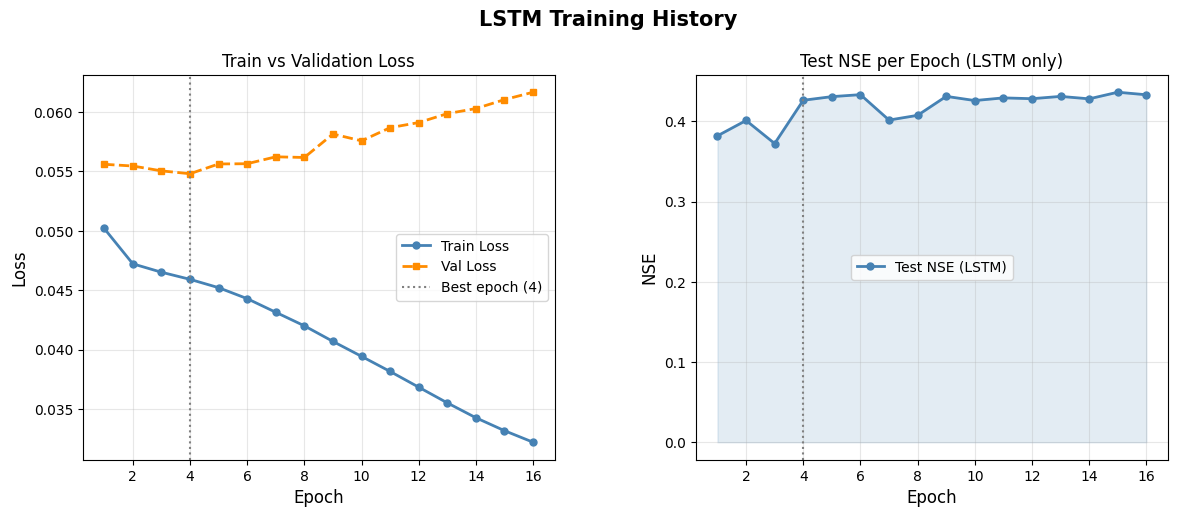

Saved: /kaggle/working/training_history.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ep    = [h['epoch']      for h in history]
tr_l  = [h['train_loss'] for h in history]
vl_l  = [h['val_loss']   for h in history]
nse_h = [h['nse_lstm']   for h in history]
lr_h  = [h['lr']         for h in history]
best_ep = min(history, key=lambda x: x['val_loss'])['epoch']

fig = plt.figure(figsize=(14, 5))
fig.suptitle("LSTM Training History", fontsize=15, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)

# Left: Loss Curves
ax1 = fig.add_subplot(gs[0])
ax1.plot(ep, tr_l, 'o-',  color='steelblue',  lw=2,   label='Train Loss', ms=5)
ax1.plot(ep, vl_l, 's--', color='darkorange',  lw=2,   label='Val Loss',   ms=5)
ax1.axvline(best_ep, color='gray', ls=':', lw=1.5,
            label=f'Best epoch ({best_ep})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Train vs Validation Loss', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: NSE per Epoch
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(ep, nse_h, alpha=0.15, color='steelblue')
ax2.plot(ep, nse_h, 'o-', color='steelblue', lw=2, ms=5, label='Test NSE (LSTM)')
ax2.axvline(best_ep, color='gray', ls=':', lw=1.5)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('NSE', fontsize=12)
ax2.set_title('Test NSE per Epoch (LSTM only)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/training_history.png")

### 13.2 Actual vs Predicted — Diagnostics

Three panels that together tell most of the diagnostic story. The time-series panel shows how well the model tracks the 500 largest flow events in the test set — this is where getting it wrong matters most. The scatter plot shows whether predictions are systematically biased at any part of the range. The residual plot shows whether the errors are random or grow with flow magnitude, which would suggest the model is under-confident at high flows.

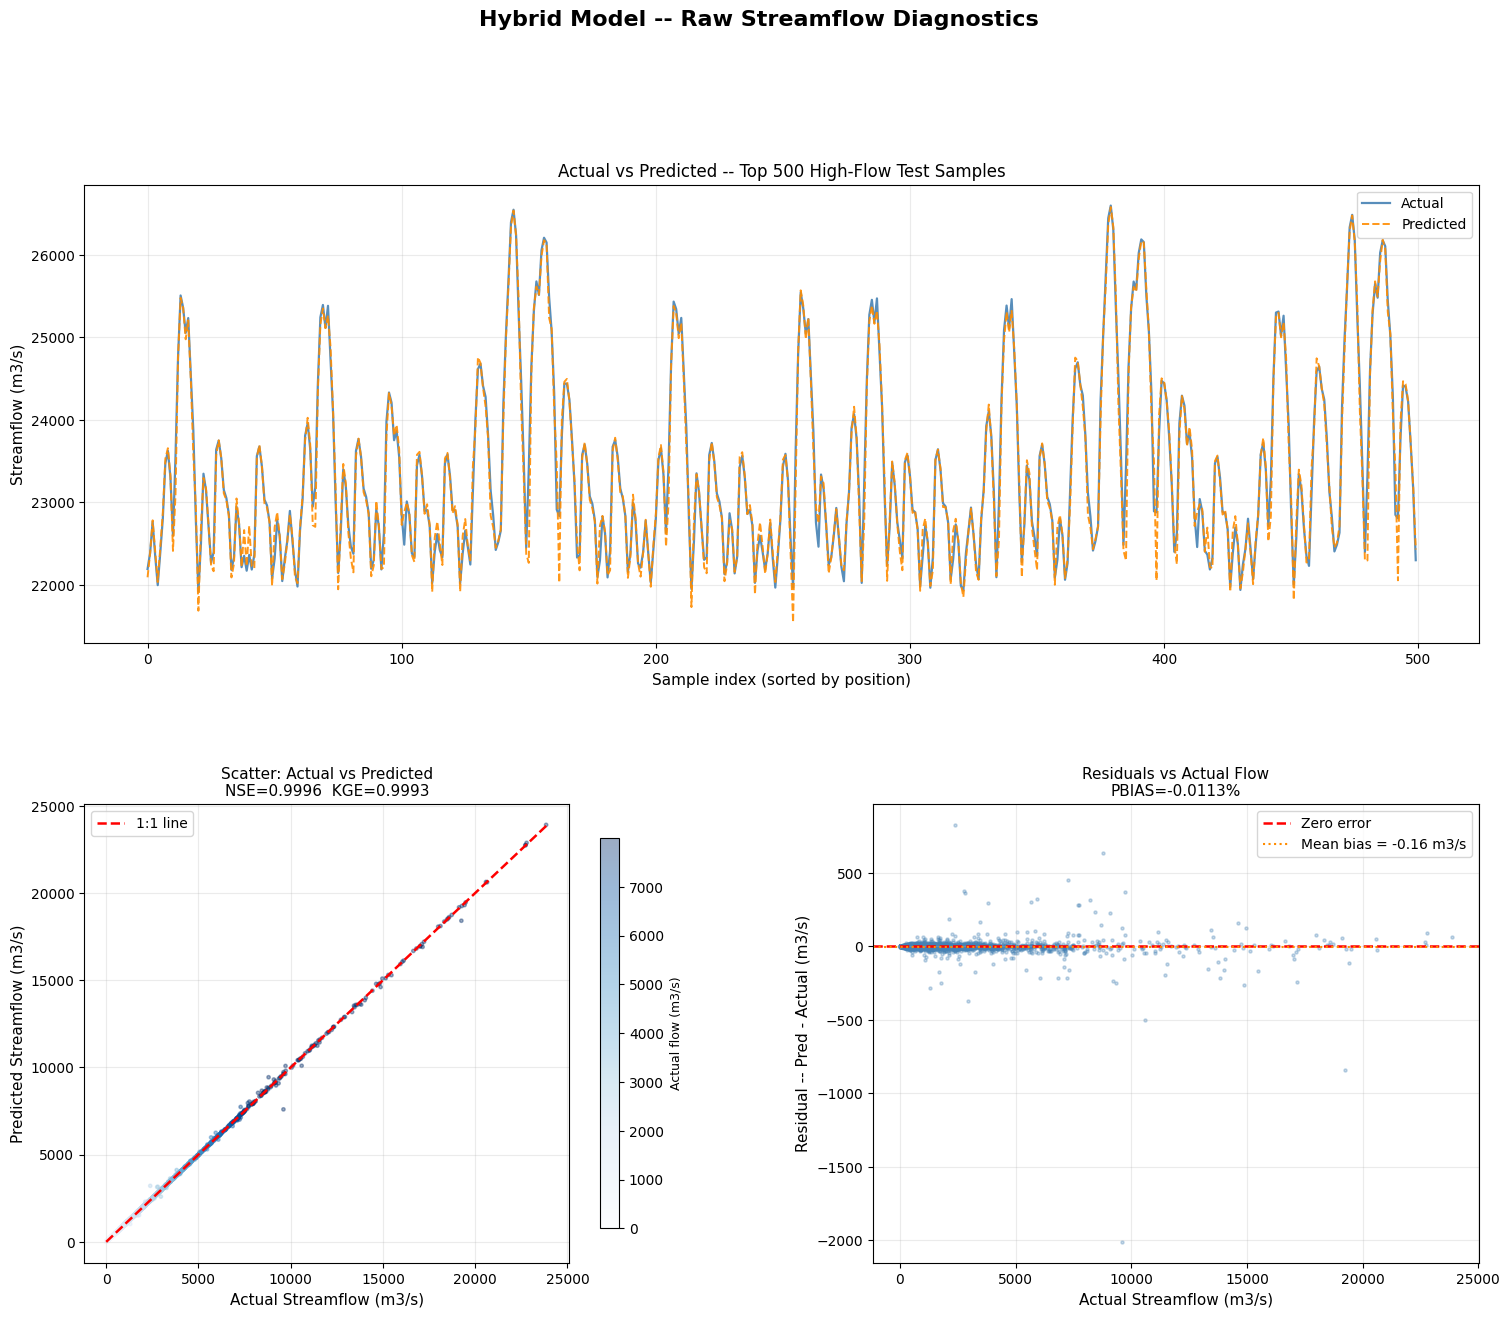

Saved: /kaggle/working/streamflow_diagnostics.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

residuals = pred_streamflow - actual_streamflow

# Downsample for plotting speed (keeps extreme values)
np.random.seed(42)
n_plot   = 6000
idx_samp = np.random.choice(len(actual_streamflow), n_plot, replace=False)
a_s = actual_streamflow[idx_samp]
p_s = pred_streamflow[idx_samp]
r_s = residuals[idx_samp]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Hybrid Model -- Raw Streamflow Diagnostics", fontsize=16,
             fontweight='bold', y=1.005)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.30)

# Panel 1: Time-series (top 500 high-flow samples ordered by magnitude)
ax1 = fig.add_subplot(gs[0, :])   # spans full top row
order = np.argsort(actual_streamflow)[::-1][:500]
order_sorted = order[np.argsort(order)]
ax1.plot(actual_streamflow[order_sorted], color='steelblue', lw=1.6,
         label='Actual', alpha=0.9)
ax1.plot(pred_streamflow[order_sorted],   color='darkorange', lw=1.4,
         ls='--', label='Predicted', alpha=0.9)
ax1.set_xlabel('Sample index (sorted by position)', fontsize=11)
ax1.set_ylabel('Streamflow (m3/s)', fontsize=11)
ax1.set_title('Actual vs Predicted -- Top 500 High-Flow Test Samples', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.25)

# Panel 2: Scatter plot
ax2 = fig.add_subplot(gs[1, 0])
sc = ax2.scatter(a_s, p_s, c=a_s, cmap='Blues', s=6, alpha=0.4,
                 vmin=0, vmax=np.percentile(a_s, 98))
cbar = plt.colorbar(sc, ax=ax2, shrink=0.85)
cbar.set_label('Actual flow (m3/s)', fontsize=9)
max_val = max(a_s.max(), p_s.max())
ax2.plot([0, max_val], [0, max_val], 'r--', lw=1.8, label='1:1 line')
ax2.set_xlabel('Actual Streamflow (m3/s)', fontsize=11)
ax2.set_ylabel('Predicted Streamflow (m3/s)', fontsize=11)
ax2.set_title(f'Scatter: Actual vs Predicted\nNSE={nse:.4f}  KGE={kge:.4f}', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.25)

# Panel 3: Residuals vs Actual
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(a_s, r_s, s=5, alpha=0.3, color='steelblue')
ax3.axhline(0, color='red',    lw=1.8, ls='--', label='Zero error')
ax3.axhline(r_s.mean(), color='darkorange', lw=1.5, ls=':',
            label=f'Mean bias = {residuals.mean():.2f} m3/s')
ax3.set_xlabel('Actual Streamflow (m3/s)', fontsize=11)
ax3.set_ylabel('Residual -- Pred - Actual (m3/s)', fontsize=11)
ax3.set_title(f'Residuals vs Actual Flow\nPBIAS={pbias:+.4f}%', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.25)

plt.savefig('/kaggle/working/streamflow_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/streamflow_diagnostics.png")

### 13.3 Residual Distribution

A well-calibrated model should have residuals that are roughly symmetric around zero with no heavy skew. A long right tail means the model is occasionally very wrong on high-flow events. A mean bias far from zero means it is systematically over- or under-predicting everywhere. We fit a normal curve over the histogram so departures from Gaussian are immediately visible.

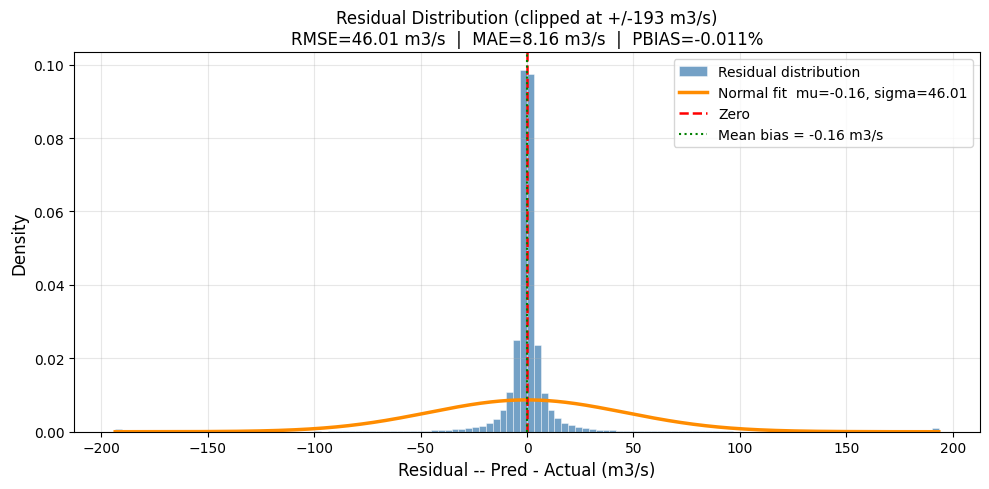

Saved: /kaggle/working/residual_distribution.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

fig, ax = plt.subplots(figsize=(10, 5))

# Clip residuals for display (keep 99.5th percentile range)
clip = np.percentile(np.abs(residuals), 99.5)
res_clipped = np.clip(residuals, -clip, clip)

counts, bins, patches = ax.hist(res_clipped, bins=120, color='steelblue',
                                 edgecolor='white', linewidth=0.4, density=True,
                                 alpha=0.75, label='Residual distribution')

# Fit a normal curve for comparison
mu, sigma = residuals.mean(), residuals.std()
x_fit = np.linspace(-clip, clip, 400)
ax.plot(x_fit, norm.pdf(x_fit, mu, sigma), 'darkorange', lw=2.5,
        label=f'Normal fit  mu={mu:.2f}, sigma={sigma:.2f}')

ax.axvline(0,  color='red',   lw=1.8, ls='--', label='Zero')
ax.axvline(mu, color='green', lw=1.5, ls=':',  label=f'Mean bias = {mu:.2f} m3/s')

ax.set_xlabel('Residual -- Pred - Actual (m3/s)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Residual Distribution (clipped at +/-{clip:.0f} m3/s)\n'
             f'RMSE={rmse:.2f} m3/s  |  MAE={mae:.2f} m3/s  |  PBIAS={pbias:+.3f}%',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/residual_distribution.png")

### 13.4 Per-Station NSE

The global NSE of 0.9996 is an aggregate number across 642k test samples. It can look good even if a handful of stations are performing poorly, because the large high-flow stations dominate the sum of squares. The honest way to evaluate a multi-station model is to compute NSE independently for each of the 367 stations and look at the distribution. We also plot NSE against mean basin flow to check whether small-basin stations are systematically harder to model.

Per-Station NSE Distribution
  Median NSE  : 0.9990
  Mean NSE    : 0.9971
  Min NSE     : 0.9669  <- worst station
  Max NSE     : 0.9999
  NSE < 0.75  : 0 stations
  NSE < 0.5   : 0 stations

  Worst 5 stations:
 station_id  mean_flow      NSE      KGE     PBIAS
         89 318.822113 0.966865 0.979006  0.091988
        255 320.966187 0.969301 0.969643  0.272594
         96 425.544373 0.979414 0.985922  0.030728
        263 297.761536 0.983702 0.978070  0.083517
        186 897.648865 0.983753 0.972173 -0.353829


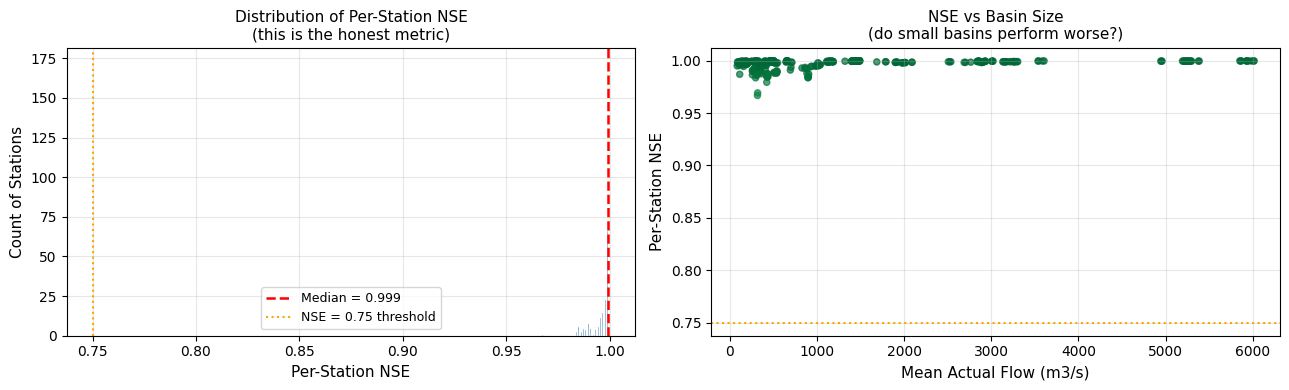

Saved: /kaggle/working/per_station_nse.png
Saved: /kaggle/working/per_station_metrics.csv


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Re-trace test indices to get station_id per test sample
test_sids = []
for sid in sorted(station_dynamic.keys()):
    n      = len(station_dynamic[sid])
    splits = station_splits[sid]
    for t in range(n - SEQ_LEN):
        if splits[t + SEQ_LEN] == 'test':
            test_sids.append(sid)

test_sids = np.array(test_sids)

# Build per-station metrics
results = []
for sid in np.unique(test_sids):
    mask = test_sids == sid
    a = actual_streamflow[mask]
    p = pred_streamflow[mask]

    ss_res = np.sum((p - a)**2)
    ss_tot = np.sum((a - a.mean())**2)
    nse_s  = 1.0 - ss_res / (ss_tot + 1e-8)
    kge_s, _, _, _ = compute_kge(p, a)
    mae_s   = np.mean(np.abs(p - a))
    pbias_s = 100 * np.sum(p - a) / (np.sum(a) + 1e-8)

    results.append({
        'station_id': sid,
        'n_samples' : mask.sum(),
        'mean_flow' : a.mean(),
        'NSE'       : nse_s,
        'KGE'       : kge_s,
        'MAE'       : mae_s,
        'PBIAS'     : pbias_s,
    })

res_df = pd.DataFrame(results).sort_values('NSE')

print("=" * 60)
print("Per-Station NSE Distribution")
print("=" * 60)
print(f"  Median NSE  : {res_df['NSE'].median():.4f}")
print(f"  Mean NSE    : {res_df['NSE'].mean():.4f}")
print(f"  Min NSE     : {res_df['NSE'].min():.4f}  <- worst station")
print(f"  Max NSE     : {res_df['NSE'].max():.4f}")
print(f"  NSE < 0.75  : {(res_df['NSE'] < 0.75).sum()} stations")
print(f"  NSE < 0.5   : {(res_df['NSE'] < 0.50).sum()} stations")
print(f"\n  Worst 5 stations:")
print(res_df[['station_id','mean_flow','NSE','KGE','PBIAS']].head(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(res_df['NSE'], bins=40, color='steelblue', edgecolor='white', lw=0.4)
axes[0].axvline(res_df['NSE'].median(), color='red', ls='--', lw=1.8,
                label=f"Median = {res_df['NSE'].median():.3f}")
axes[0].axvline(0.75, color='orange', ls=':', lw=1.5, label='NSE = 0.75 threshold')
axes[0].set_xlabel('Per-Station NSE', fontsize=11)
axes[0].set_ylabel('Count of Stations', fontsize=11)
axes[0].set_title('Distribution of Per-Station NSE\n(this is the honest metric)', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].scatter(res_df['mean_flow'], res_df['NSE'],
                c=res_df['NSE'], cmap='RdYlGn', s=20, alpha=0.7,
                vmin=0.5, vmax=1.0)
axes[1].axhline(0.75, color='orange', ls=':', lw=1.5)
axes[1].set_xlabel('Mean Actual Flow (m3/s)', fontsize=11)
axes[1].set_ylabel('Per-Station NSE', fontsize=11)
axes[1].set_title('NSE vs Basin Size\n(do small basins perform worse?)', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/per_station_nse.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/per_station_nse.png")

res_df.to_csv('/kaggle/working/per_station_metrics.csv', index=False)
print("Saved: /kaggle/working/per_station_metrics.csv")

### 13.5 Station Hydrographs

Aggregate statistics only tell you so much. Looking at actual time-series overlays for individual stations reveals things numbers cannot — whether the model tracks the recession curve correctly, whether it under-predicts the peak by a consistent margin, whether it is ahead or behind in timing. We pick the best, median, and worst station by NSE so the range of behaviour is visible in one figure.

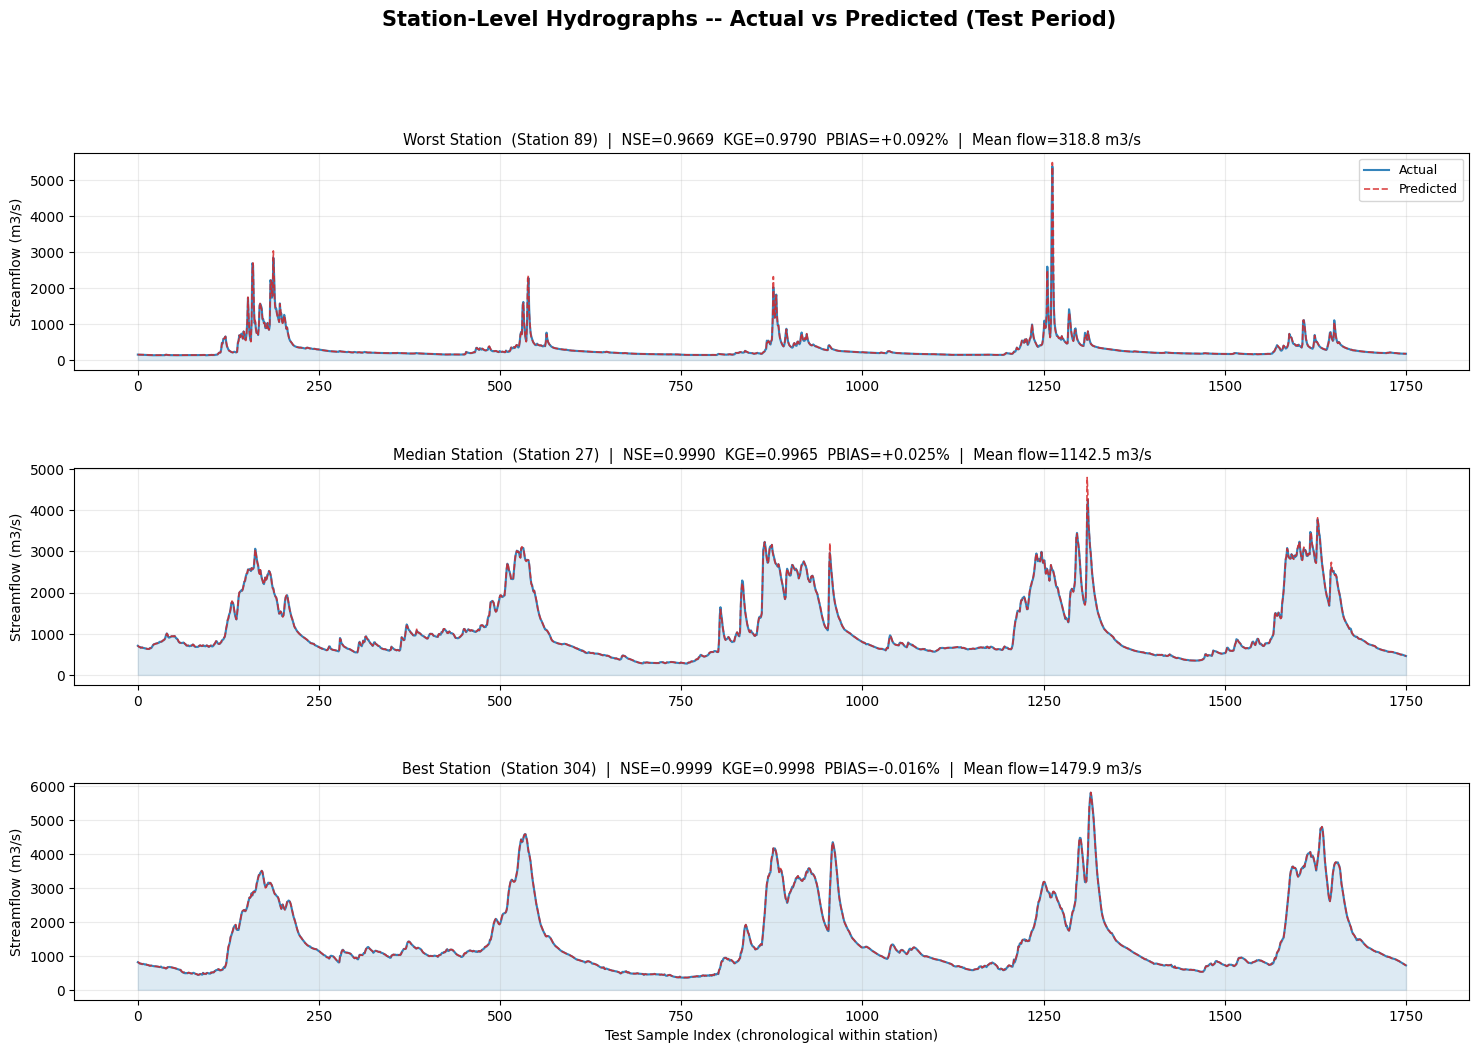

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Pick 3 representative stations from res_df
worst_sid  = res_df.iloc[0]['station_id']
median_sid = res_df.iloc[len(res_df)//2]['station_id']
best_sid   = res_df.iloc[-1]['station_id']

stations_to_plot = [
    (worst_sid,  'Worst Station',  res_df[res_df.station_id==worst_sid].iloc[0]),
    (median_sid, 'Median Station', res_df[res_df.station_id==median_sid].iloc[0]),
    (best_sid,   'Best Station',   res_df[res_df.station_id==best_sid].iloc[0]),
]

fig = plt.figure(figsize=(18, 11))
fig.suptitle("Station-Level Hydrographs -- Actual vs Predicted (Test Period)",
             fontsize=15, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

colors = {'actual': '#1f77b4', 'pred': '#d62728'}

for row_idx, (sid, label, row) in enumerate(stations_to_plot):
    mask   = test_sids == sid
    a_flow = actual_streamflow[mask]
    p_flow = pred_streamflow[mask]
    x      = np.arange(len(a_flow))

    ax = fig.add_subplot(gs[row_idx])
    ax.fill_between(x, a_flow, alpha=0.15, color=colors['actual'])
    ax.plot(x, a_flow, lw=1.5, color=colors['actual'], label='Actual', alpha=0.9)
    ax.plot(x, p_flow, lw=1.2, color=colors['pred'],   label='Predicted',
            ls='--', alpha=0.85)

    nse_s   = row['NSE']
    kge_s   = row['KGE']
    pbias_s = row['PBIAS']
    mean_s  = row['mean_flow']

    ax.set_title(
        f"{label}  (Station {int(sid)})  |  "
        f"NSE={nse_s:.4f}  KGE={kge_s:.4f}  "
        f"PBIAS={pbias_s:+.3f}%  |  Mean flow={mean_s:.1f} m3/s",
        fontsize=10.5
    )
    ax.set_ylabel("Streamflow (m3/s)", fontsize=10)
    ax.grid(True, alpha=0.25)
    if row_idx == 0:
        ax.legend(loc='upper right', fontsize=9)

ax.set_xlabel("Test Sample Index (chronological within station)", fontsize=10)
plt.tight_layout()
plt.show()

### 13.6 Flow Duration Curve

A flow duration curve (FDC) ranks all observed flows by exceedance probability. If the predicted FDC lies close to the actual one across the full range — from the driest days at the right tail to the biggest floods at the left — the model is preserving the statistical distribution of flow, not just tracking average conditions. The log-scale panel is especially important because it is the only way to see what is happening at low flows where absolute errors are small but relative errors can be large.

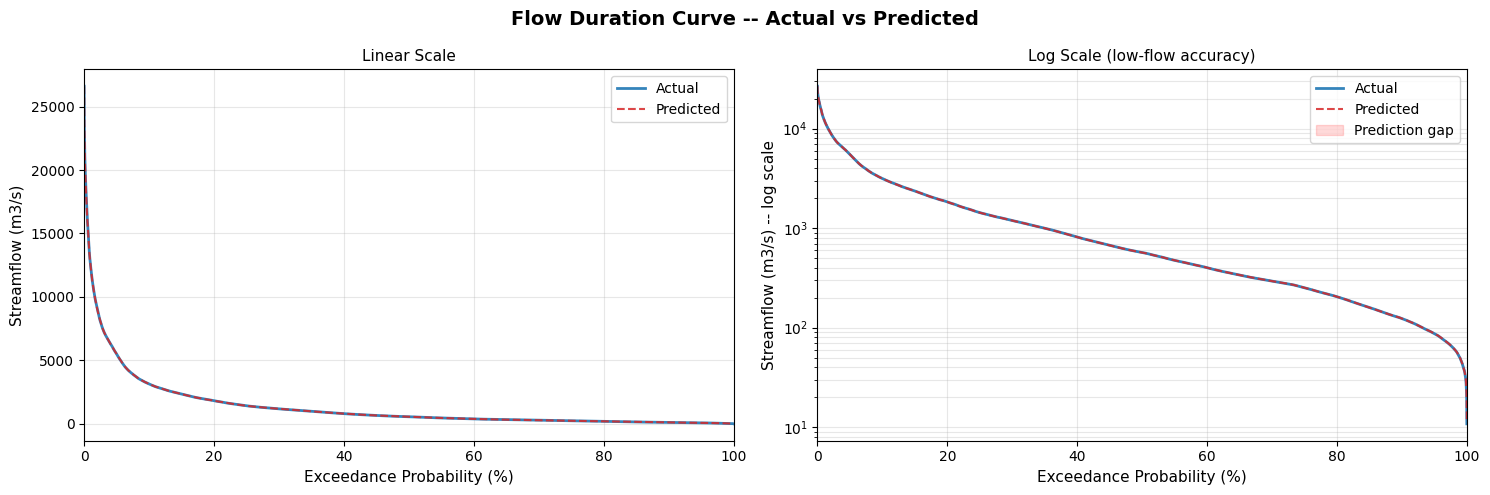

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def fdc(flow_array):
    sorted_flow = np.sort(flow_array)[::-1]
    exceedance  = np.arange(1, len(sorted_flow)+1) / len(sorted_flow) * 100
    return exceedance, sorted_flow

exc_a, fdc_a = fdc(actual_streamflow)
exc_p, fdc_p = fdc(pred_streamflow)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Flow Duration Curve -- Actual vs Predicted", fontsize=14,
             fontweight='bold')

# Left: Linear scale (focus on high flows)
axes[0].plot(exc_a, fdc_a, lw=2,   color='#1f77b4', label='Actual',    alpha=0.9)
axes[0].plot(exc_p, fdc_p, lw=1.5, color='#d62728', label='Predicted',
             ls='--', alpha=0.85)
axes[0].set_xlabel('Exceedance Probability (%)', fontsize=11)
axes[0].set_ylabel('Streamflow (m3/s)', fontsize=11)
axes[0].set_title('Linear Scale', fontsize=11)
axes[0].set_xlim(0, 100)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: Log scale (reveals low-flow accuracy)
axes[1].semilogy(exc_a, np.maximum(fdc_a, 1e-3), lw=2,   color='#1f77b4',
                 label='Actual', alpha=0.9)
axes[1].semilogy(exc_p, np.maximum(fdc_p, 1e-3), lw=1.5, color='#d62728',
                 label='Predicted', ls='--', alpha=0.85)

# Shade the area between -- highlights bias at any percentile
axes[1].fill_between(exc_a,
    np.maximum(fdc_a, 1e-3),
    np.interp(exc_a, exc_p, np.maximum(fdc_p, 1e-3)),
    alpha=0.15, color='red', label='Prediction gap')

axes[1].set_xlabel('Exceedance Probability (%)', fontsize=11)
axes[1].set_ylabel('Streamflow (m3/s) -- log scale', fontsize=11)
axes[1].set_title('Log Scale (low-flow accuracy)', fontsize=11)
axes[1].set_xlim(0, 100)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

### 13.7 Error by Flow Quantile

It is easy to have low overall error simply because 85% of the test samples are baseflow and errors there are small in absolute terms. Splitting the test set into 20 equal-frequency bins by actual flow magnitude forces an honest look at each part of the range. If error is concentrated in the upper bins, the model is struggling specifically at flood peaks. If the bias changes sign across bins, the model is systematically shifting between over- and under-prediction as flow increases.

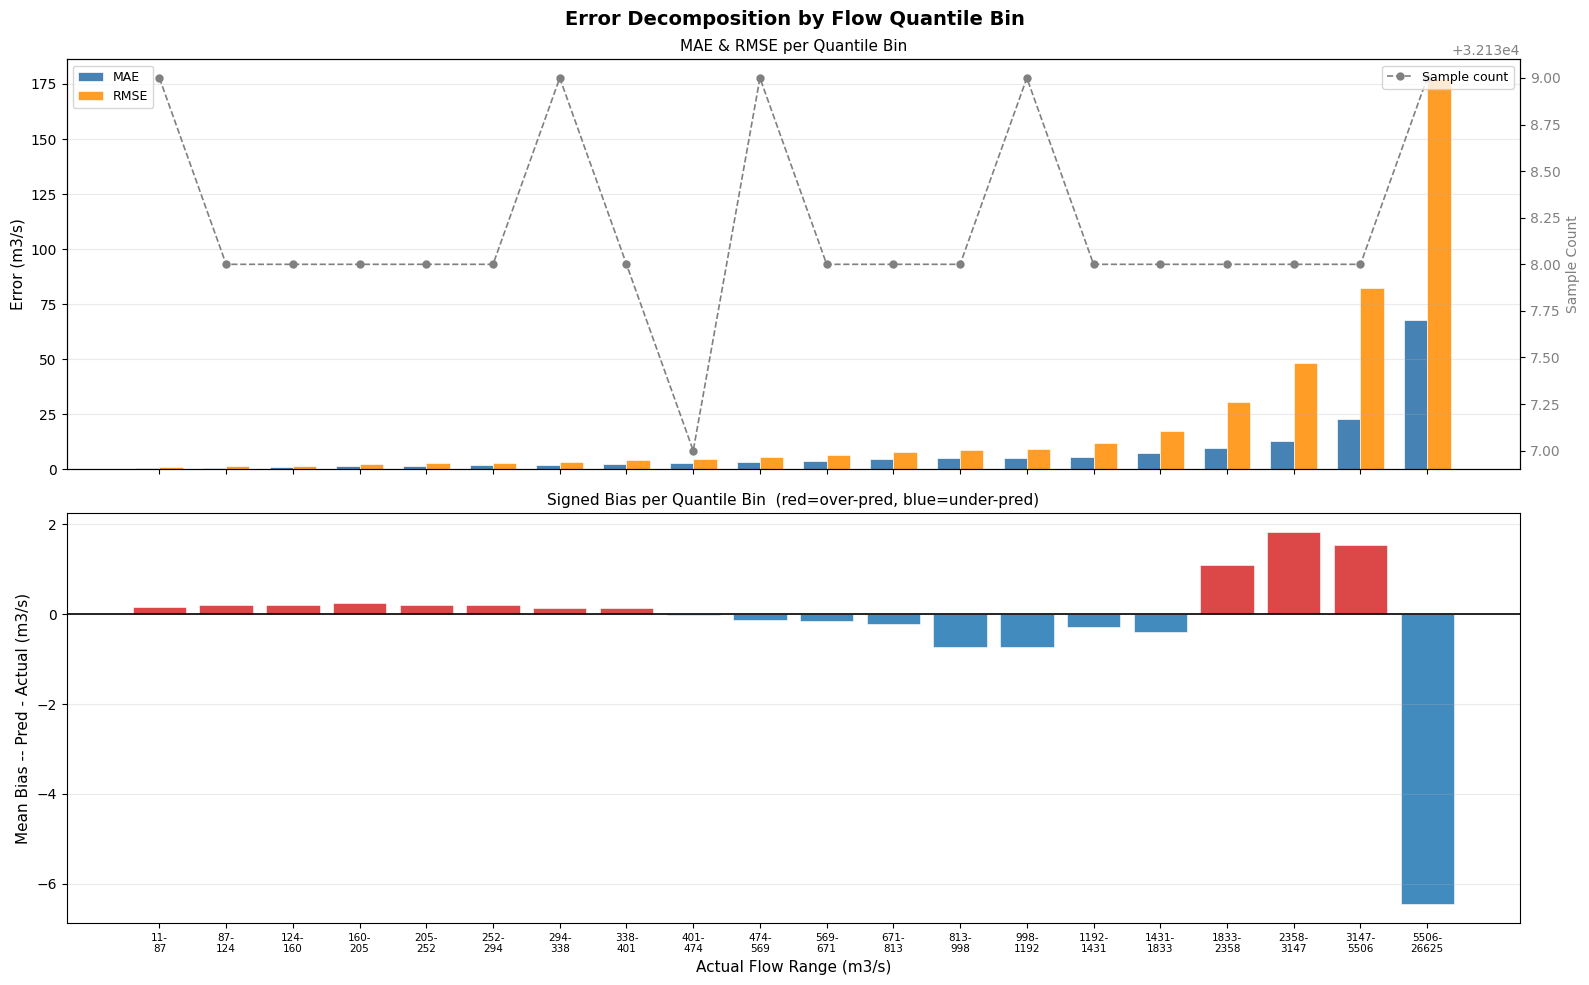

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

n_bins   = 20
quantile_edges = np.percentile(actual_streamflow, np.linspace(0, 100, n_bins+1))
quantile_edges[-1] *= 1.001  # ensure max is included

bin_labels, bin_mae, bin_rmse, bin_bias, bin_count, bin_center = \
    [], [], [], [], [], []

for i in range(n_bins):
    lo, hi = quantile_edges[i], quantile_edges[i+1]
    mask   = (actual_streamflow >= lo) & (actual_streamflow < hi)
    if mask.sum() < 5:
        continue
    a, p  = actual_streamflow[mask], pred_streamflow[mask]
    res   = p - a
    bin_mae.append(np.mean(np.abs(res)))
    bin_rmse.append(np.sqrt(np.mean(res**2)))
    bin_bias.append(res.mean())
    bin_count.append(mask.sum())
    bin_center.append((lo + hi) / 2)
    bin_labels.append(f"{lo:.0f}-\n{hi:.0f}")

x      = np.arange(len(bin_labels))
colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(bin_labels)))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle("Error Decomposition by Flow Quantile Bin",
             fontsize=14, fontweight='bold')

# Top: MAE and RMSE bars
bar_w = 0.35
axes[0].bar(x - bar_w/2, bin_mae,  width=bar_w, label='MAE',
            color='steelblue', edgecolor='white', lw=0.5)
axes[0].bar(x + bar_w/2, bin_rmse, width=bar_w, label='RMSE',
            color='darkorange', edgecolor='white', lw=0.5, alpha=0.85)

ax0r = axes[0].twinx()
ax0r.plot(x, bin_count, 'o--', color='grey', ms=5, lw=1.2, label='Sample count')
ax0r.set_ylabel('Sample Count', fontsize=10, color='grey')
ax0r.tick_params(axis='y', labelcolor='grey')

axes[0].set_ylabel('Error (m3/s)', fontsize=11)
axes[0].set_title('MAE & RMSE per Quantile Bin', fontsize=11)
axes[0].legend(loc='upper left',  fontsize=9)
ax0r.legend(loc='upper right',    fontsize=9)
axes[0].grid(True, alpha=0.25, axis='y')

# Bottom: Signed bias
bar_colors = ['#d62728' if b > 0 else '#1f77b4' for b in bin_bias]
axes[1].bar(x, bin_bias, color=bar_colors, edgecolor='white', lw=0.5, alpha=0.85)
axes[1].axhline(0, color='black', lw=1.2, ls='-')
axes[1].set_ylabel('Mean Bias -- Pred - Actual (m3/s)', fontsize=11)
axes[1].set_title('Signed Bias per Quantile Bin  (red=over-pred, blue=under-pred)',
                  fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_labels, fontsize=7.5)
axes[1].set_xlabel('Actual Flow Range (m3/s)', fontsize=11)
axes[1].grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

### 13.8 Seasonal Performance

The monsoon season (roughly June to October in this basin network) brings an order-of-magnitude increase in daily flow. A model trained on the full year can look excellent on an annual basis while quietly failing during the 4–5 months that actually matter for flood risk. Monthly NSE and RMSE panels break this down, with the monsoon window shaded in each plot. The mean flow panel at bottom right gives context — so you know how much variance the model is being asked to explain each month.

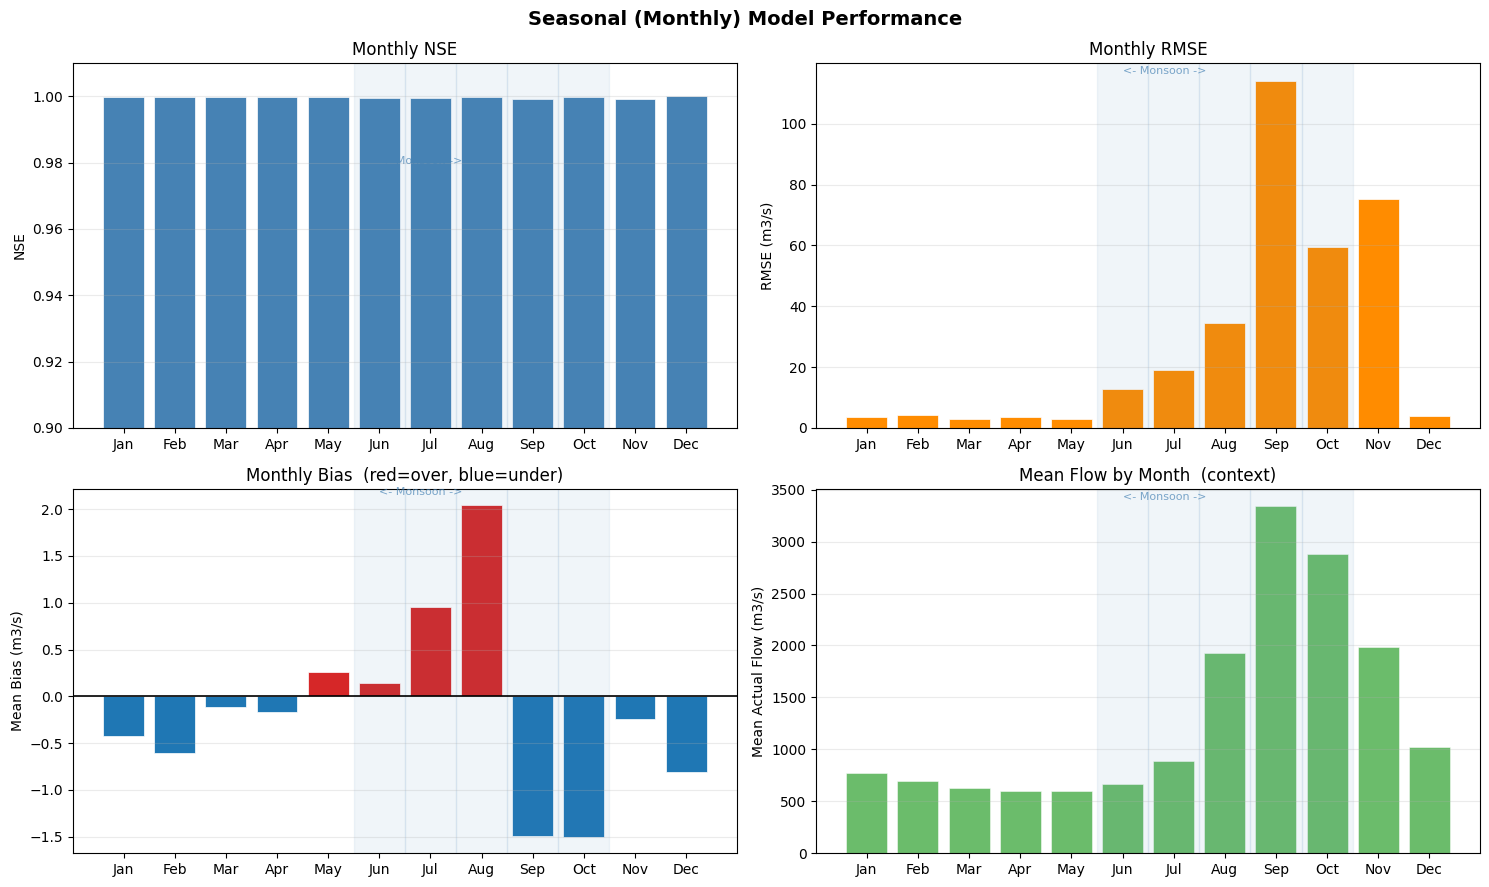

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recover month for each test sample via month_sin/cos
# month_sin = sin(2*pi*(month-1)/12), month_cos = cos(2*pi*(month-1)/12)
mid   = DYNAMIC_COLS.index('month_sin')
mid_c = DYNAMIC_COLS.index('month_cos')

test_months = []
for sid in sorted(station_dynamic.keys()):
    n      = len(station_dynamic[sid])
    splits = station_splits[sid]
    for t in range(n - SEQ_LEN):
        if splits[t + SEQ_LEN] == 'test':
            sin_val = station_dynamic[sid][t + SEQ_LEN, mid]
            cos_val = station_dynamic[sid][t + SEQ_LEN, mid_c]
            angle   = np.arctan2(sin_val, cos_val)        # [-pi, pi]
            month   = int(np.round(angle * 12 / (2*np.pi))) % 12 + 1
            test_months.append(month)

test_months = np.array(test_months)
residuals   = pred_streamflow - actual_streamflow

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = []
for m in range(1, 13):
    mask = test_months == m
    if mask.sum() < 10:
        continue
    a, p = actual_streamflow[mask], pred_streamflow[mask]
    r    = p - a
    ss_res = np.sum((p-a)**2)
    ss_tot = np.sum((a-a.mean())**2)
    nse_m  = 1.0 - ss_res / (ss_tot + 1e-8)
    monthly.append({
        'month': m, 'name': month_names[m-1],
        'NSE':   nse_m,
        'MAE':   np.mean(np.abs(r)),
        'RMSE':  np.sqrt(np.mean(r**2)),
        'Bias':  r.mean(),
        'Mean_flow': a.mean(),
        'n': mask.sum()
    })

mdf = pd.DataFrame(monthly)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle("Seasonal (Monthly) Model Performance", fontsize=14,
             fontweight='bold')

monsoon_months = [6, 7, 8, 9, 10]   # Jun-Oct: shade these

def shade_monsoon(ax):
    for m in monsoon_months:
        if m-1 < len(mdf):
            ax.axvspan(m-1-0.5, m-1+0.5, alpha=0.08,
                       color='steelblue', label='_')

# NSE
axes[0,0].bar(mdf.index, mdf['NSE'], color='steelblue',
              edgecolor='white', lw=0.5)
shade_monsoon(axes[0,0])
axes[0,0].set_xticks(mdf.index); axes[0,0].set_xticklabels(mdf['name'])
axes[0,0].axhline(0.75, color='orange', ls=':', lw=1.5)
axes[0,0].set_ylim(0.9, 1.01)
axes[0,0].set_ylabel('NSE'); axes[0,0].set_title('Monthly NSE')
axes[0,0].grid(True, alpha=0.25, axis='y')

# RMSE
axes[0,1].bar(mdf.index, mdf['RMSE'], color='darkorange',
              edgecolor='white', lw=0.5)
shade_monsoon(axes[0,1])
axes[0,1].set_xticks(mdf.index); axes[0,1].set_xticklabels(mdf['name'])
axes[0,1].set_ylabel('RMSE (m3/s)'); axes[0,1].set_title('Monthly RMSE')
axes[0,1].grid(True, alpha=0.25, axis='y')

# Bias
bias_colors = ['#d62728' if b > 0 else '#1f77b4' for b in mdf['Bias']]
axes[1,0].bar(mdf.index, mdf['Bias'], color=bias_colors,
              edgecolor='white', lw=0.5)
shade_monsoon(axes[1,0])
axes[1,0].axhline(0, color='black', lw=1.2)
axes[1,0].set_xticks(mdf.index); axes[1,0].set_xticklabels(mdf['name'])
axes[1,0].set_ylabel('Mean Bias (m3/s)')
axes[1,0].set_title('Monthly Bias  (red=over, blue=under)')
axes[1,0].grid(True, alpha=0.25, axis='y')

# Mean flow context
axes[1,1].bar(mdf.index, mdf['Mean_flow'], color='#2ca02c',
              edgecolor='white', lw=0.5, alpha=0.7, label='Mean flow')
shade_monsoon(axes[1,1])
axes[1,1].set_xticks(mdf.index); axes[1,1].set_xticklabels(mdf['name'])
axes[1,1].set_ylabel('Mean Actual Flow (m3/s)')
axes[1,1].set_title('Mean Flow by Month  (context)')
axes[1,1].grid(True, alpha=0.25, axis='y')

# Annotate monsoon band
for ax in axes.flat:
    ax.annotate('<- Monsoon ->', xy=(5, ax.get_ylim()[1]*0.97),
                fontsize=8, color='steelblue', alpha=0.7)

plt.tight_layout()
plt.show()

### 13.9 KGE Decomposition Across All Stations

KGE = 1 is the ideal. But knowing a station has KGE = 0.92 does not tell you why it is not 1.0. Is the timing slightly off? Is the model predicting too much variability? Is there a volume bias? By decomposing KGE into r (correlation), α (variability ratio), and β (bias ratio) for each of the 367 stations and plotting each component against mean basin flow, you can see whether any component has a systematic relationship with basin size — which would point to a specific modelling weakness rather than random error.

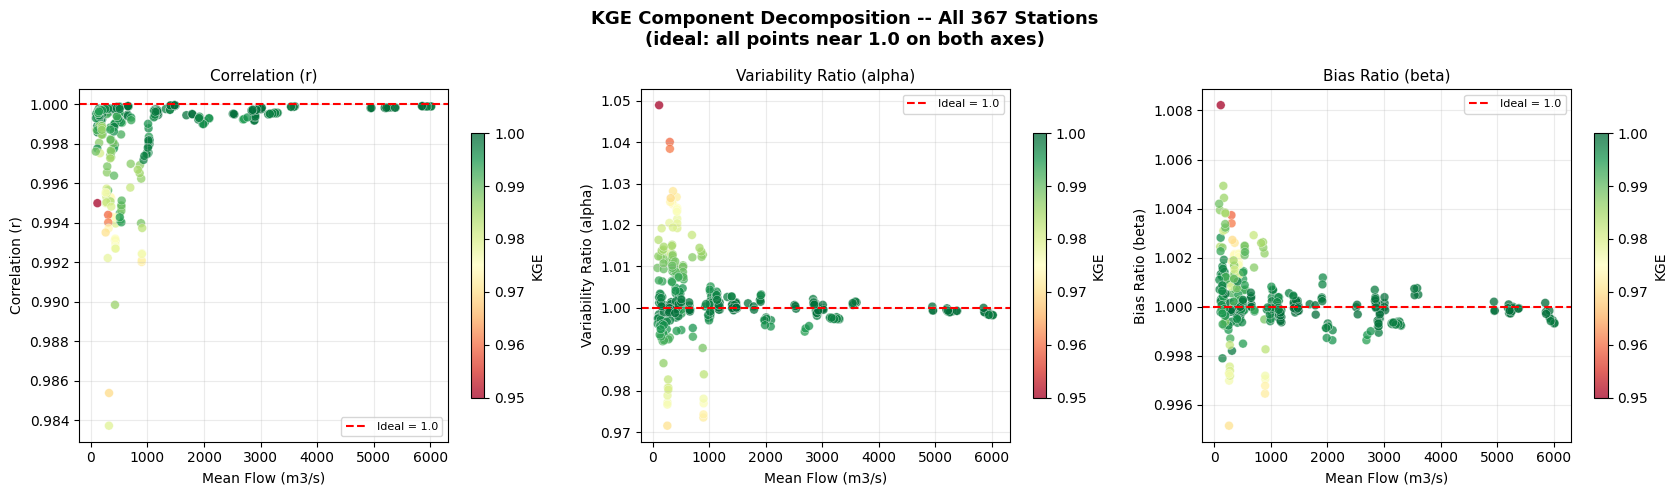

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

station_kge_components = []
for sid in np.unique(test_sids):
    mask = test_sids == sid
    a = actual_streamflow[mask]
    p = pred_streamflow[mask]
    r     = np.corrcoef(a, p)[0, 1]
    alpha = p.std()  / (a.std()  + 1e-8)
    beta  = p.mean() / (a.mean() + 1e-8)
    kge   = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    station_kge_components.append({
        'sid': sid, 'r': r, 'alpha': alpha,
        'beta': beta, 'kge': kge,
        'mean_flow': a.mean()
    })

kdf = pd.DataFrame(station_kge_components)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("KGE Component Decomposition -- All 367 Stations\n"
             "(ideal: all points near 1.0 on both axes)",
             fontsize=13, fontweight='bold')

components = [
    ('r',     'Correlation (r)',          'steelblue'),
    ('alpha', 'Variability Ratio (alpha)', 'darkorange'),
    ('beta',  'Bias Ratio (beta)',         '#2ca02c'),
]

for i, (col, clabel, color) in enumerate(components):
    sc = axes[i].scatter(
        kdf['mean_flow'], kdf[col],
        c=kdf['kge'], cmap='RdYlGn',
        s=40, alpha=0.75, vmin=0.95, vmax=1.0,
        edgecolors='white', lw=0.3
    )
    axes[i].axhline(1.0, color='red', ls='--', lw=1.5, label='Ideal = 1.0')
    axes[i].set_xlabel('Mean Flow (m3/s)', fontsize=10)
    axes[i].set_ylabel(clabel, fontsize=10)
    axes[i].set_title(clabel, fontsize=11)
    axes[i].grid(True, alpha=0.25)
    axes[i].legend(fontsize=8)
    plt.colorbar(sc, ax=axes[i], label='KGE', shrink=0.75)

plt.tight_layout()
plt.show()